# Lección 2.2 · Bases de datos biológicas: NCBI, Ensembl, UniProt y PDB desde Python

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-02-formatos-bases-datos/2.2_bases_de_datos.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 2 — Secuencias, formatos y bases de datos** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3 horas | Intermedio | Lecciones 0.1–0.3, Módulo 1 y Lección 2.1 |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Distinguir** bases de datos primarias (archivos de datos crudos) de bases curadas y derivadas, y **explicar**
   para qué sirve cada una.
2. **Seguir el rastro** de un mismo gen a través de sus identificadores: gen → transcrito → proteína → estructura.
3. **Explicar** qué es una API REST (URL, parámetros, códigos de estado HTTP, JSON) y **consultarla** con `requests`.
4. **Usar** las E-utilities del NCBI (`esearch`, `esummary`, `elink`, `efetch`) respetando sus límites de uso.
5. **Descargar** y **visualizar** el modelo génico de Ensembl, las regiones funcionales y variantes de UniProt, y las
   estructuras 3D del PDB.
6. **Programar** consultas robustas: con reintentos, caché, copia de respaldo y registro de procedencia
   (*provenance*).

## 🗺️ Mapa de la clase

1. El mapa de las bases de datos biológicas
2. Hablar con una base de datos: APIs REST, URLs y JSON
3. Un cliente robusto: límites de uso, reintentos, caché y respaldo
4. 🧪 NCBI: el gen *TP53* y el crecimiento de la literatura en PubMed
5. 🧪 Ensembl: el modelo génico de *TP53* (exones, intrones y transcritos)
6. 🧪 UniProt: dominios de p53 y el mapa de sus mutaciones en cáncer
7. 🧪 PDB: las estructuras 3D de p53
8. Todo junto: una tabla integrada con procedencia
9. Ejercicios, resumen y lecturas

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import json, time, pathlib, tempfile, datetime
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import requests

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"
print("requests", requests.__version__)

Entorno listo ✔  |  Colab: False
requests 2.34.2


## 1. El mapa de las bases de datos biológicas

Cada día, laboratorios de todo el mundo producen secuencias, estructuras y mediciones. Si cada grupo guardara sus
datos en su propia computadora, la biología sería un archipiélago de islas incomunicadas. Por eso, desde los años
80, la comunidad acordó **depositar** los datos en grandes repositorios públicos, gratuitos y sincronizados entre sí.

Una buena manera de ordenar este paisaje es pensar en una biblioteca universitaria:

* Los **archivos primarios** son como el **depósito de tesis**: guardan lo que cada autor envió, tal cual, con su
  firma. Nadie corrige el contenido; sólo se verifica el formato. Ejemplos: **GenBank/ENA/DDBJ** (secuencias de
  ácidos nucleicos), **SRA** (lecturas crudas de secuenciación), **PDB** (estructuras 3D).
* Las **bases curadas** son como la **enciclopedia** de la biblioteca: expertos leen muchas fuentes, eliminan
  redundancias, corrigen errores y resumen el conocimiento en una sola entrada por entidad. Ejemplos: **RefSeq**
  (secuencias de referencia del NCBI), **UniProtKB/Swiss-Prot** (proteínas revisadas a mano).
* Las **bases derivadas o integradoras** son como el **catálogo temático**: toman lo anterior y lo organizan para
  una pregunta concreta. Ejemplos: **Ensembl** y **NCBI Gene** (genes anotados sobre un genoma), **Pfam/InterPro**
  (familias de proteínas), **ClinVar** (variantes y enfermedad).

| Tipo | ¿Quién escribe? | ¿Redundante? | Ejemplos | Úsela cuando… |
|---|---|---|---|---|
| Primaria | El autor que deposita | Sí (muchas copias del mismo gen) | GenBank, SRA, PDB | necesita el dato original y citable |
| Curada | Curadores expertos | No (una entrada por entidad) | RefSeq, Swiss-Prot | necesita **la** secuencia de referencia |
| Derivada | Algoritmos + curadores | No | Ensembl, NCBI Gene, Pfam | necesita contexto: genoma, función, familia |

La consecuencia práctica más importante es que **un mismo gen tiene muchos identificadores**, uno por base de datos.
En esta clase seguiremos al gen más estudiado de la biología humana, ***TP53***, que codifica la proteína **p53**, el
"guardián del genoma": está mutado en aproximadamente la mitad de los cánceres humanos.

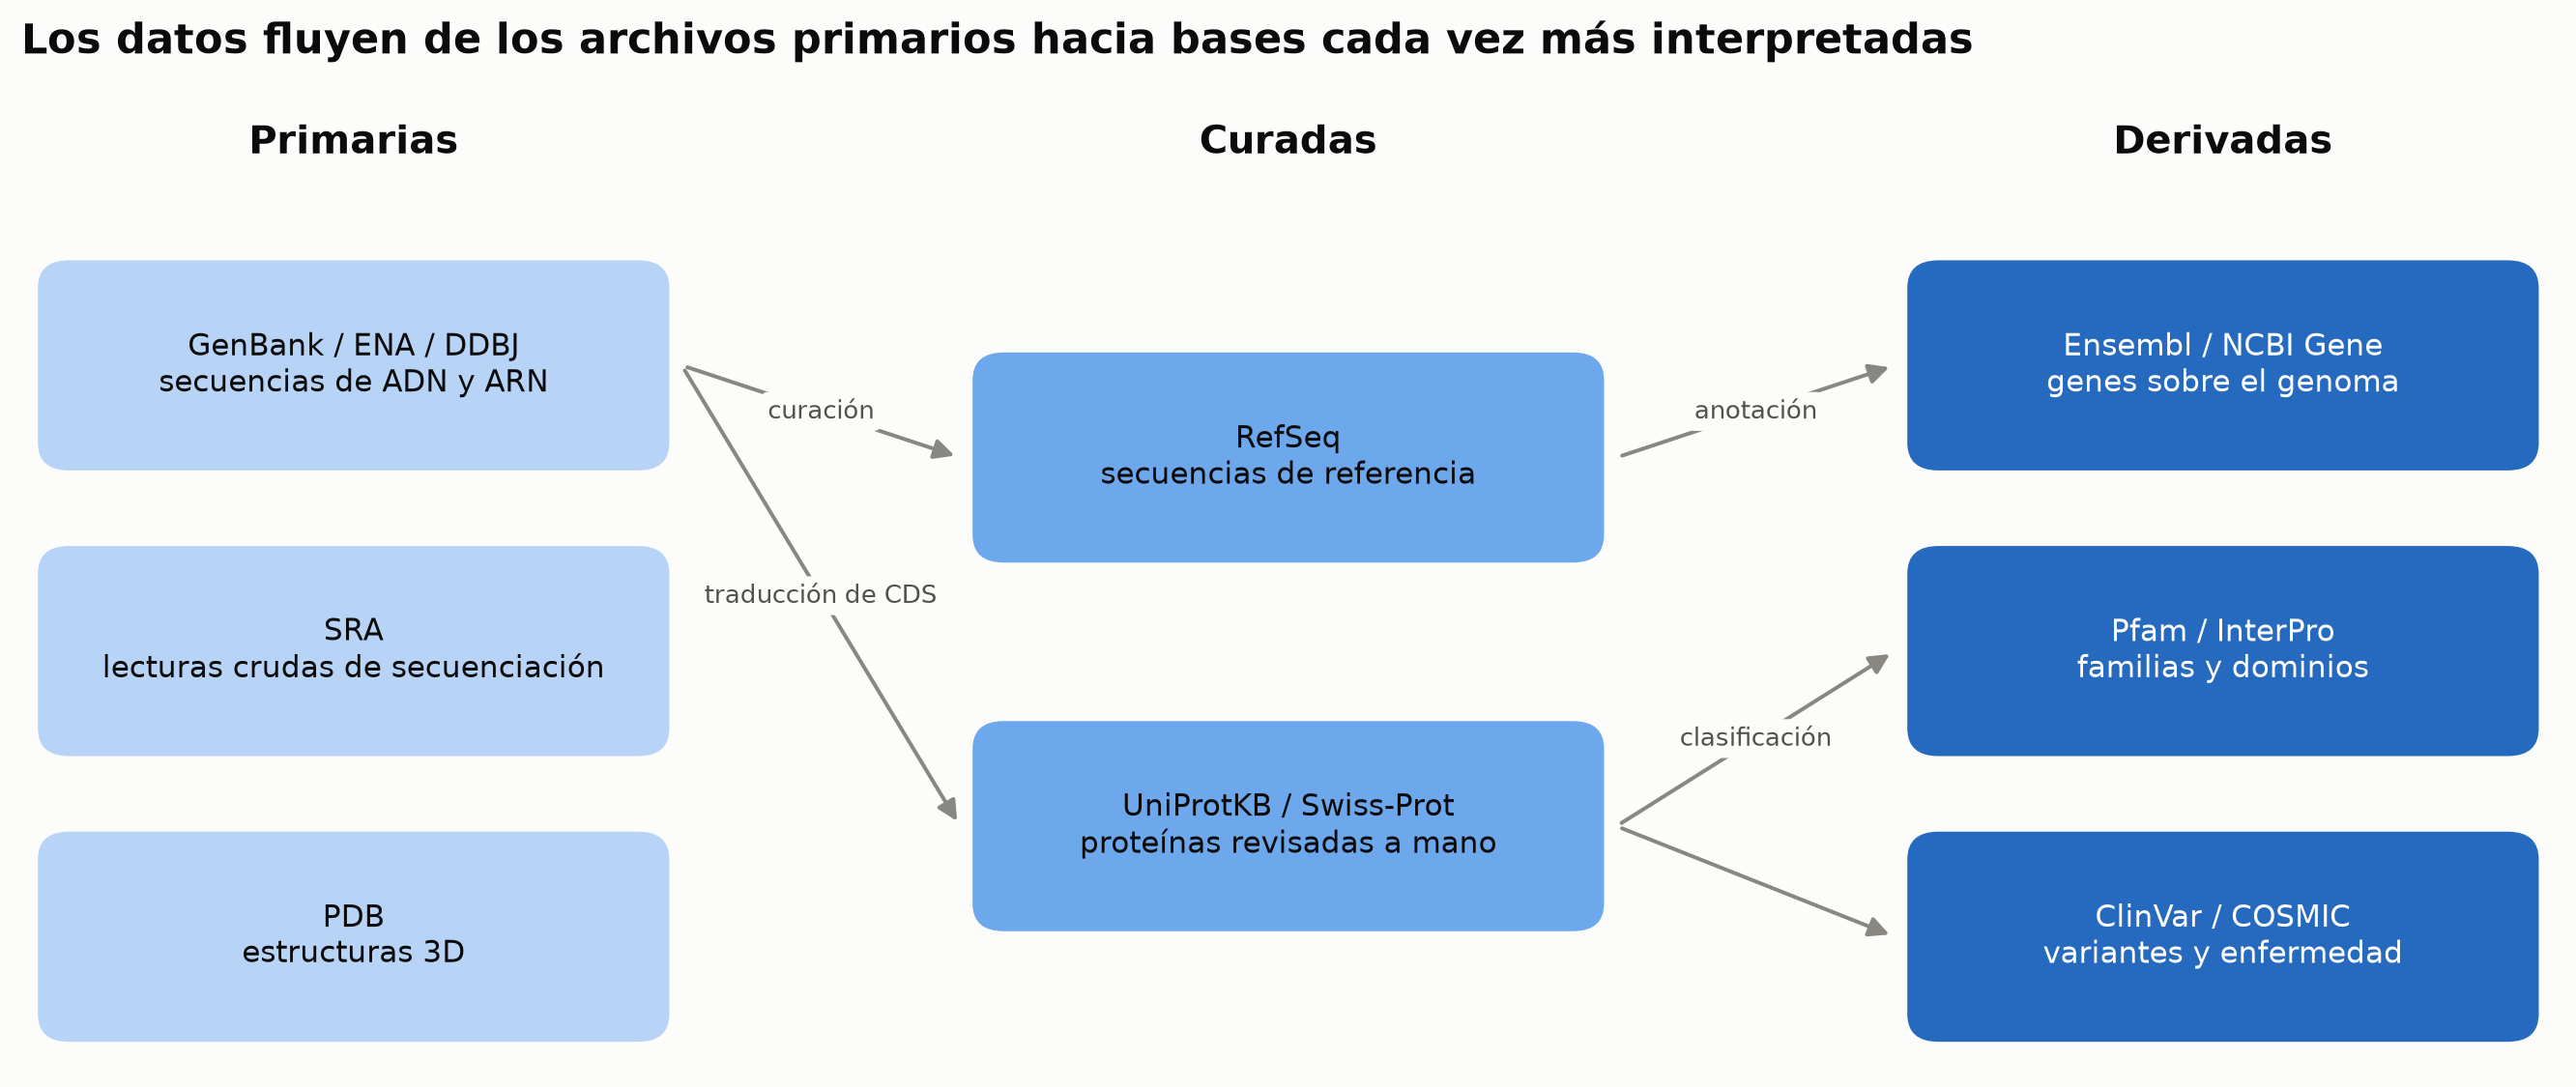

In [2]:
# Diagrama: el paisaje de las bases de datos y cómo fluyen los datos entre ellas
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12, 5.0))
ax.set_xlim(0, 12.2); ax.set_ylim(0.9, 6.2); ax.axis("off"); ax.grid(False)

W = 3.0                                                     # ancho de cada caja
cols = {"Primarias": (0.1, ec.SEQ_BLUE[1]), "Curadas": (4.6, ec.SEQ_BLUE[4]), "Derivadas": (9.1, ec.SEQ_BLUE[8])}
boxes = {
    "Primarias": ["GenBank / ENA / DDBJ\nsecuencias de ADN y ARN", "SRA\nlecturas crudas de secuenciación",
                  "PDB\nestructuras 3D"],
    "Curadas":   ["RefSeq\nsecuencias de referencia", "UniProtKB / Swiss-Prot\nproteínas revisadas a mano"],
    "Derivadas": ["Ensembl / NCBI Gene\ngenes sobre el genoma", "Pfam / InterPro\nfamilias y dominios",
                  "ClinVar / COSMIC\nvariantes y enfermedad"],
}
centers = {}
for col, (x0, color) in cols.items():
    ax.text(x0 + W / 2, 5.85, col, ha="center", fontsize=13, fontweight="bold", color=ec.INK)
    n = len(boxes[col])
    for i, label in enumerate(boxes[col]):
        y = 4.7 - i * 1.55 if n == 3 else 4.2 - i * 2.0
        text_color = "white" if col == "Derivadas" else ec.INK
        ax.add_patch(FancyBboxPatch((x0, y - 0.55), W, 1.1, boxstyle="round,pad=0.02,rounding_size=0.15",
                                    fc=color, ec="none"))
        ax.text(x0 + W / 2, y, label, ha="center", va="center", fontsize=10, color=text_color)
        centers[label.split("\n")[0]] = (x0, y)

def arrow(a, b, text=None):
    (xa, ya), (xb, yb) = centers[a], centers[b]
    ax.add_patch(FancyArrowPatch((xa + W + 0.08, ya), (xb - 0.08, yb), arrowstyle="-|>", mutation_scale=14,
                                 color=ec.MUTED, lw=1.3))
    if text:
        ax.text((xa + W + xb) / 2, (ya + yb) / 2, text, ha="center", va="center", fontsize=8.5, color=ec.INK_2,
                bbox=dict(boxstyle="round,pad=0.25", fc=ec.SURFACE, ec="none"))

arrow("GenBank / ENA / DDBJ", "RefSeq", "curación")
arrow("GenBank / ENA / DDBJ", "UniProtKB / Swiss-Prot", "traducción de CDS")
arrow("RefSeq", "Ensembl / NCBI Gene", "anotación")
arrow("UniProtKB / Swiss-Prot", "Pfam / InterPro", "clasificación")
arrow("UniProtKB / Swiss-Prot", "ClinVar / COSMIC", "")
ax.set_title("Los datos fluyen de los archivos primarios hacia bases cada vez más interpretadas", loc="left")
plt.show()

> 🔎 **Qué observamos.** Las flechas van de izquierda a derecha: la **evidencia** entra por los archivos primarios y
> se va **interpretando**. Cuanto más a la derecha, más cómoda es la información para un humano, pero más depende de
> decisiones de otras personas (y de la **versión** de la base de datos). Por eso siempre registraremos de dónde y
> cuándo sacamos cada dato.

✅ **Compruebe su comprensión.** Usted necesita la secuencia *exacta* que un grupo reportó en un artículo de 2009.
¿Busca en GenBank o en RefSeq? ¿Y si necesita "la" proteína humana p53 que todo el mundo usa como referencia?

## 2. Hablar con una base de datos: APIs REST, URLs y JSON

Usted puede entrar a la página web del NCBI y buscar *TP53* con el ratón. Pero ¿y si necesita hacerlo para 5 000
genes? Para eso existen las **APIs** (*Application Programming Interfaces*): puertas de servicio pensadas para que
**un programa**, y no una persona, haga las preguntas.

Funciona como pedir en una ventanilla con un formulario estándar:

1. Usted llena un **formulario** (la **URL** con sus **parámetros**).
2. Lo entrega en la **ventanilla** correcta (el **servidor** de la base de datos).
3. El empleado le devuelve un **sello** que dice si todo salió bien (el **código de estado HTTP**) y un **sobre**
   con la respuesta (casi siempre en formato **JSON**).

Una API que sigue estas convenciones de la web se llama **REST**.

### Anatomía de una URL

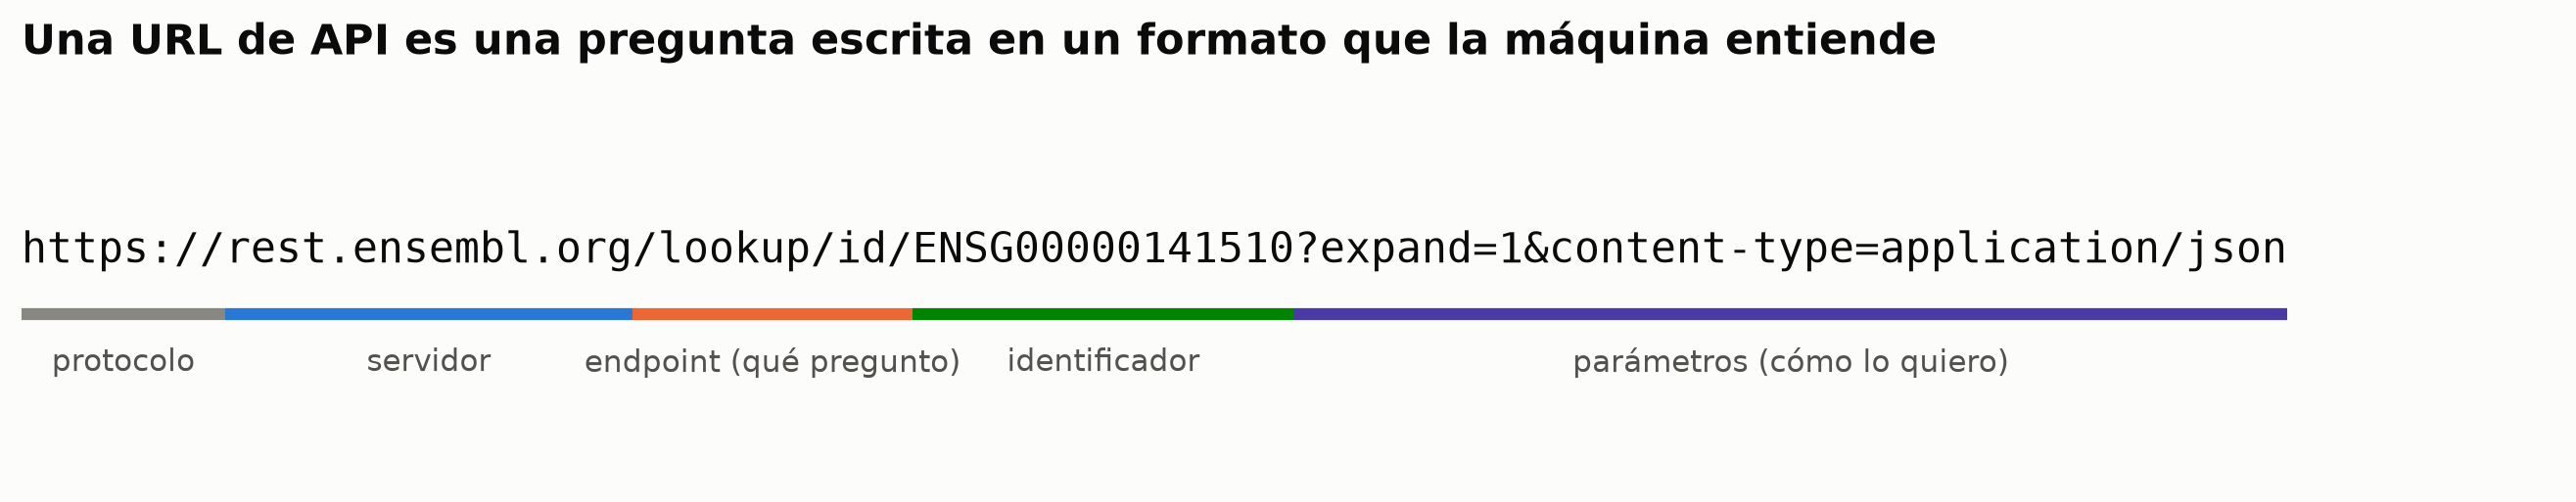

In [3]:
# Anatomía de una petición a la API de Ensembl
parts = [("https://", "protocolo", ec.MUTED),
         ("rest.ensembl.org", "servidor", ec.BLUE),
         ("/lookup/id/", "endpoint (qué pregunto)", ec.ORANGE),
         ("ENSG00000141510", "identificador", ec.GREEN),
         ("?expand=1&content-type=application/json", "parámetros (cómo lo quiero)", ec.VIOLET)]

fig = plt.figure(figsize=(12, 2.2), layout="none")      # sin reacomodo automático: medimos el texto en su lugar final
ax = fig.add_axes([0.01, 0.0, 0.98, 0.78])
ax.axis("off"); ax.grid(False); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
renderer = fig.canvas.get_renderer()
x = 0.0
for text, label, color in parts:
    t = ax.text(x, 0.62, text, fontsize=14, family="DejaVu Sans Mono", color=ec.INK, va="center")
    bb = t.get_window_extent(renderer=renderer).transformed(ax.transData.inverted())
    ax.plot([bb.x0, bb.x1], [0.45, 0.45], color=color, lw=4, solid_capstyle="butt")
    ax.text((bb.x0 + bb.x1) / 2, 0.36, label, ha="center", va="top", fontsize=10, color=ec.INK_2)
    x = bb.x1
fig.suptitle("Una URL de API es una pregunta escrita en un formato que la máquina entiende", x=0.01, y=0.97,
             ha="left", fontsize=14, fontweight="bold")
plt.show()

### Los códigos de estado HTTP: el "sello" de la respuesta

| Código | Significado | Qué hacer |
|---|---|---|
| `200 OK` | Todo bien, aquí está la respuesta | Leer el contenido |
| `400 Bad Request` | La pregunta está mal formulada (p. ej. un identificador inexistente) | Revisar la URL |
| `404 Not Found` | El recurso no existe | Revisar el endpoint |
| `429 Too Many Requests` | Usted está preguntando demasiado rápido | **Esperar** y reintentar |
| `500`–`503` | El servidor tiene problemas | Esperar y reintentar |

🤔 **Antes de ejecutar, prediga:** si pedimos a Ensembl un identificador que no existe, ¿qué código recibiremos?

In [4]:
try:
    ok = requests.get("https://rest.ensembl.org/lookup/id/ENSG00000141510", params={"expand": 1},
                      headers={"Content-Type": "application/json"}, timeout=30)
    bad = requests.get("https://rest.ensembl.org/lookup/id/ENSG_NO_EXISTE",
                       headers={"Content-Type": "application/json"}, timeout=30)
    print("Identificador real      →", ok.status_code, "| tipo de contenido:", ok.headers.get("Content-Type"))
    print("Identificador inventado →", bad.status_code, "|", bad.text[:80])
except requests.RequestException as err:
    ok = None
    print("Sin conexión con Ensembl en este momento:", err, "→ usaremos la copia del curso")

Identificador real      → 200 | tipo de contenido: application/json
Identificador inventado → 400 | {"error":"ID 'ENSG_NO_EXISTE' not found"}


### JSON: diccionarios y listas anidados

La respuesta llega como texto en formato **JSON** (*JavaScript Object Notation*). Para Python es una estructura
familiar: **diccionarios** (`{"clave": valor}`) y **listas** (`[a, b, c]`) anidados unos dentro de otros, como
carpetas dentro de carpetas. `response.json()` lo convierte directamente en objetos de Python.

In [5]:
if ok is not None and ok.status_code == 200:
    gene_json = ok.json()
else:                                   # respaldo: la misma respuesta guardada en el repositorio del curso
    local_copy = "../data/api_cache/ensembl_lookup_ENSG00000141510.json"
    gene_json = (json.load(open(local_copy)) if os.path.exists(local_copy) else
                 requests.get(f"{RAW}/data/api_cache/ensembl_lookup_ENSG00000141510.json", timeout=60).json())
print("Claves de primer nivel:", list(gene_json)[:14], "...")
print("Nombre:", gene_json["display_name"], "| cromosoma:", gene_json["seq_region_name"],
      "| hebra:", gene_json["strand"], "| n.º de transcritos:", len(gene_json["Transcript"]))
# Un vistazo a la estructura anidada: gen → transcritos → exones
t0 = gene_json["Transcript"][0]
print("Primer transcrito:", t0["id"], "→ primer exón:", {k: t0["Exon"][0][k] for k in ("id", "start", "end")})

Claves de primer nivel: ['start', 'logic_name', 'source', 'object_type', 'canonical_transcript', 'end', 'biotype', 'description', 'id', 'db_type', 'seq_region_name', 'version', 'Transcript', 'display_name'] ...
Nombre: TP53 | cromosoma: 17 | hebra: -1 | n.º de transcritos: 40
Primer transcrito: ENST00000413465 → primer exón: {'id': 'ENSE00002337729', 'start': 7676521, 'end': 7676594}


## 3. Un cliente robusto: límites de uso, reintentos, caché y respaldo

Los servidores públicos atienden a millones de usuarios, así que imponen **límites de velocidad**. El NCBI, por
ejemplo, admite **3 peticiones por segundo** sin registro y **10 por segundo** con una **API key** gratuita (se
obtiene en la configuración de su cuenta del NCBI y se envía con el parámetro `api_key`). Si usted excede el límite,
el servidor responde `429` y, si insiste, puede bloquear su dirección IP.

### Cálculo a mano: ¿cuánto tarda una consulta masiva?

Si necesitamos $N$ peticiones y el servidor permite $r$ peticiones por segundo, el tiempo mínimo es

$$
T_{\min} \;=\; \frac{N}{r}
$$

| Símbolo | Significado |
|---|---|
| $N$ | número de peticiones que necesitamos |
| $r$ | tasa máxima permitida (peticiones/segundo) |
| $T_{\min}$ | tiempo mínimo total, en segundos |

Para contar artículos de PubMed año por año (26 años) de 3 temas necesitamos $N = 78$ peticiones: sin API key,
$T_{\min} = 78/3 = 26$ s; con API key, $78/10 \approx 7.8$ s. Para 20 000 genes serían casi 2 horas sin key: ahí
conviene usar descargas masivas (FTP) en lugar de la API.

### Reintentos con espera exponencial

Cuando una petición falla por un problema pasajero (`429`, `5xx`, red caída), lo correcto es **esperar y
reintentar**, pero cada vez un poco más, para no empeorar la congestión:

$$
t_k \;=\; b \cdot 2^{\,k}, \qquad k = 0, 1, 2, \dots
$$

| Símbolo | Significado |
|---|---|
| $k$ | número de reintento (0 = primer reintento) |
| $b$ | espera base (p. ej. 1 s) |
| $t_k$ | segundos a esperar antes del reintento $k$: 1, 2, 4, 8… |

Es lo mismo que hacemos al llamar por teléfono a una línea ocupada: no marcamos cada segundo, esperamos cada vez un
poco más.

![Vista previa: un cliente impaciente recibe errores 429; uno respetuoso (3 peticiones/s) recibe todo con 200.](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-02-formatos-bases-datos/2.2_limite_tasa.gif)

*Vista previa: un cliente impaciente recibe errores 429; uno respetuoso (3 peticiones/s) recibe todo con 200.*

In [6]:
# 🎬 Animación: dos clientes piden 12 datos a un servidor que admite 3 peticiones por segundo
rate, n_req = 3, 12
greedy_t = np.linspace(0, 0.6, n_req)                    # dispara todo en 0.6 s
polite_t = np.arange(n_req) / rate                        # una petición cada 1/3 s

def server_status(times, rate):
    """El servidor acepta como máximo `rate` peticiones en cualquier ventana de 1 s."""
    status, accepted = [], []
    for t in times:
        recent = [a for a in accepted if t - a < 1.0]
        if len(recent) < rate:
            accepted.append(t); status.append(200)
        else:
            status.append(429)
    return np.array(status)

greedy_s, polite_s = server_status(greedy_t, rate), server_status(polite_t, rate)
t_end = polite_t[-1] + 0.4
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.set_xlim(-0.1, t_end); ax.set_ylim(-0.7, 1.9)
ax.set_yticks([0, 1]); ax.set_yticklabels(["cliente respetuoso\n(3 por segundo)", "cliente impaciente\n(todo de golpe)"])
ax.set_xlabel("tiempo (s)"); ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_title("Límite de 3 peticiones/s: preguntar más rápido no da respuestas más rápido", loc="left")
dots_g = ax.scatter([], [], s=140, zorder=3); dots_p = ax.scatter([], [], s=140, zorder=3)
clock = ax.axvline(0, color=ec.MUTED, lw=1)
score = ax.text(t_end, 1.72, "", ha="right", fontsize=10, color=ec.INK_2)
color = {200: ec.GREEN, 429: ec.RED}
frames = 45
def update(f):
    now = f / (frames - 1) * t_end
    for dots, times, st, y in [(dots_g, greedy_t, greedy_s, 1), (dots_p, polite_t, polite_s, 0)]:
        m = times <= now
        dots.set_offsets(np.column_stack([times[m], np.full(m.sum(), y)]) if m.any() else np.empty((0, 2)))
        dots.set_color([color[s] for s in st[m]])
        dots.set_edgecolor(ec.SURFACE); dots.set_linewidth(2)
    clock.set_xdata([now, now])
    g_ok = int(((greedy_t <= now) & (greedy_s == 200)).sum()); p_ok = int(((polite_t <= now) & (polite_s == 200)).sum())
    score.set_text(f"t = {now:4.1f} s · respuestas válidas: impaciente {g_ok} / respetuoso {p_ok}   "
                   "(verde = 200 OK, rojo = 429)")
    return dots_g, dots_p, clock, score
ec.animate(fig, update, frames=frames, interval=110, name="2.2_limite_tasa")

> 🔎 **Qué observamos.** El cliente impaciente termina de "preguntar" en 0.6 s, pero sólo 3 de sus 12 peticiones
> reciben respuesta: las otras 9 son rechazadas con `429` y tendría que repetirlas. El cliente respetuoso tarda
> $12/3 = 4$ s y recibe **todo** a la primera.

### Nuestro cliente del curso: `fetch()`

Juntemos todas las buenas prácticas en una sola función que usaremos el resto de la clase (y del curso):

1. **Caché local:** si ya pedimos algo, no lo volvemos a pedir (ahorra tiempo y respeta al servidor).
   Y si un servidor no responde, no insistimos con él durante el resto de la sesión.
2. **Ritmo por servicio:** espera mínima entre peticiones a un mismo servidor (NCBI: 0.34 s).
3. **Reintentos** con espera exponencial ante `429`, `5xx` o errores de red.
4. **Respaldo:** si todo falla (sin internet, servidor caído), usa una copia guardada en el repositorio del curso.
5. **Procedencia:** anota qué se pidió, a quién, cuándo y de dónde salió la respuesta.

In [7]:
CACHE = pathlib.Path(tempfile.gettempdir()) / "curso_api_cache"     # caché de esta sesión
CACHE.mkdir(exist_ok=True)
BACKUP_URL = f"{RAW}/data/api_cache"
LOCAL_BACKUP = pathlib.Path("../data/api_cache")                   # si trabaja con el repositorio clonado
MIN_INTERVAL = {"ncbi": 0.34, "ensembl": 0.07, "uniprot": 0.1, "rcsb": 0.1}   # segundos entre peticiones
NCBI_PARAMS = {"tool": "bioinformatica_practica", "email": "su.correo@ejemplo.com"}  # ← su correo
# NCBI_PARAMS["api_key"] = "..."   # opcional: con API key el límite sube de 3 a 10 peticiones/s
_last_call, PROVENANCE = {}, []
_offline = set()        # servicios que no respondieron: no insistimos durante esta sesión

def _http(url, service, params=None, json_body=None, retries=4, base_wait=1.0):
    """Petición HTTP con ritmo por servicio y reintentos con espera exponencial."""
    for k in range(retries + 1):
        wait = MIN_INTERVAL.get(service, 0.1) - (time.time() - _last_call.get(service, 0))
        if wait > 0:
            time.sleep(wait)                          # respetar el ritmo del servidor
        _last_call[service] = time.time()
        try:
            if json_body is None:
                r = requests.get(url, params=params, headers={"Accept": "application/json"}, timeout=60)
            else:
                r = requests.post(url, json=json_body, timeout=60)
        except (requests.ConnectionError, requests.Timeout):
            if k == retries:
                raise
            time.sleep(base_wait * 2 ** k)            # t_k = b · 2^k
            continue
        if (r.status_code == 429 or r.status_code >= 500) and k < retries:
            time.sleep(base_wait * 2 ** k)            # problema pasajero: esperar y reintentar
            continue
        r.raise_for_status()                          # 4xx: la pregunta está mal → no tiene sentido reintentar
        return r.text

def fetch(key, url, service, params=None, json_body=None, fmt="json", simulate_failure=False):
    """Consulta una API con caché, reintentos, respaldo y registro de procedencia."""
    path = CACHE / key
    if path.exists() and not simulate_failure:
        text, source = path.read_text(), "caché de la sesión"
    else:
        try:
            if simulate_failure:
                raise requests.ConnectionError("fallo de red simulado")
            if service in _offline:
                raise requests.ConnectionError(f"{service} no respondió antes en esta sesión")
            text, source = _http(url, service, params, json_body), "API en vivo"
            if fmt == "json":
                json.loads(text)                      # respuesta incompleta o corrupta → usar el respaldo
        except Exception as err:
            if isinstance(err, (requests.ConnectionError, requests.Timeout)) and not simulate_failure:
                _offline.add(service)
            if (LOCAL_BACKUP / key).exists():
                text = (LOCAL_BACKUP / key).read_text()
            else:
                backup = requests.get(f"{BACKUP_URL}/{key}", timeout=60)
                backup.raise_for_status()
                text = backup.text
            source = f"respaldo del curso ({type(err).__name__})"
        path.write_text(text)
    PROVENANCE.append({"key": key, "service": service, "url": url, "source": source,
                       "retrieved": datetime.datetime.now().isoformat(timespec="seconds")})
    return json.loads(text) if fmt == "json" else text

print("Caché en:", CACHE)

Caché en: /var/folders/v6/7qpl2n5x40913m5whl1jmsmm0000gn/T/curso_api_cache


Probemos el **respaldo**: simulamos que se cayó el internet justo cuando pedimos el gen a Ensembl.

In [8]:
ENSEMBL = "https://rest.ensembl.org"
tp53_ens = fetch("ensembl_lookup_ENSG00000141510.json", f"{ENSEMBL}/lookup/id/ENSG00000141510", "ensembl",
                 params={"expand": 1, "content-type": "application/json"}, simulate_failure=True)
print("¿Obtuvimos el gen a pesar del fallo?", tp53_ens["display_name"], "→ fuente:", PROVENANCE[-1]["source"])

¿Obtuvimos el gen a pesar del fallo? TP53 → fuente: respaldo del curso (ConnectionError)


## 4. 🧪 NCBI: el gen *TP53* y el crecimiento de la literatura

El NCBI ofrece las **E-utilities**, una familia de "ventanillas" que se combinan como piezas de LEGO:

| Utilidad | Pregunta que responde | Devuelve |
|---|---|---|
| `esearch` | ¿Qué registros cumplen esta búsqueda? | lista de identificadores (UIDs) y el conteo |
| `esummary` | ¿Qué dice el resumen de estos registros? | metadatos (nombre, cromosoma, posición…) |
| `elink` | ¿Qué registros de **otra** base están ligados a estos? | UIDs relacionados (gen → proteínas, artículos…) |
| `efetch` | Dame el registro completo | FASTA, GenBank, XML… |

El flujo típico es **esearch → esummary/elink → efetch**: primero se encuentra, luego se mira, al final se descarga.

In [9]:
EUTILS = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils"

search = fetch("ncbi_esearch_gene_TP53_human.json", f"{EUTILS}/esearch.fcgi", "ncbi",
               params={"db": "gene", "term": "TP53[sym] AND human[orgn]", "retmode": "json", **NCBI_PARAMS})
gene_id = search["esearchresult"]["idlist"][0]
print("esearch → NCBI Gene ID de TP53 humano:", gene_id)

summary = fetch(f"ncbi_esummary_gene_{gene_id}.json", f"{EUTILS}/esummary.fcgi", "ncbi",
                params={"db": "gene", "id": gene_id, "retmode": "json", **NCBI_PARAMS})
g = summary["result"][gene_id]
loc = g["genomicinfo"][0]
print(f"esummary → {g['name']}: {g['description']} · cromosoma {g['chromosome']} ({g['maplocation']})")
print(f"            {loc['chraccver']}: chrstart={loc['chrstart']:,}  chrstop={loc['chrstop']:,}  exones={loc['exoncount']}")
print("Resumen:", g["summary"][:260], "…")

esearch → NCBI Gene ID de TP53 humano: 7157
esummary → TP53: tumor protein p53 · cromosoma 17 (17p13.1)
            NC_000017.11: chrstart=7,687,489  chrstop=7,668,420  exones=13
Resumen: This gene encodes a tumor suppressor protein containing transcriptional activation, DNA binding, and oligomerization domains. The encoded protein responds to diverse cellular stresses to regulate expression of target genes, thereby inducing cell cycle arrest,  …


### Una trampa clásica: coordenadas en base 0 y en base 1

Observe que `chrstart` es **mayor** que `chrstop`. No es un error: *TP53* está en la **hebra negativa** del
cromosoma 17, y el NCBI reporta "inicio" y "fin" en el sentido de lectura del gen. Además, el `esummary` del NCBI usa
coordenadas **en base 0**, mientras que Ensembl y los navegadores usan **base 1**:

$$
x_{\text{base 1}} \;=\; x_{\text{base 0}} + 1
\qquad\qquad
\text{longitud} \;=\; x_{\text{fin}} - x_{\text{inicio}} + 1 \quad(\text{intervalo cerrado, base 1})
$$

| Símbolo | Significado |
|---|---|
| $x_{\text{base 0}}$ | posición contando desde 0 (como los índices de Python) |
| $x_{\text{base 1}}$ | posición contando desde 1 (como los biólogos) |

Comprobémoslo comparando con el transcrito canónico de Ensembl: si la conversión es correcta, los números deben
coincidir exactamente.

In [10]:
canon = next(t for t in tp53_ens["Transcript"] if t.get("is_canonical"))
ncbi_start_1based = min(loc["chrstart"], loc["chrstop"]) + 1
ncbi_end_1based = max(loc["chrstart"], loc["chrstop"]) + 1
print(f"NCBI (convertido a base 1): {ncbi_start_1based:,} – {ncbi_end_1based:,}")
print(f"Ensembl, transcrito canónico {canon['id']}: {canon['start']:,} – {canon['end']:,}")
print("¿Coinciden?", (ncbi_start_1based, ncbi_end_1based) == (canon["start"], canon["end"]))
print(f"Longitud del locus: {canon['end'] - canon['start'] + 1:,} pb")

NCBI (convertido a base 1): 7,668,421 – 7,687,490
Ensembl, transcrito canónico ENST00000269305: 7,668,421 – 7,687,490
¿Coinciden? True
Longitud del locus: 19,070 pb


### `elink` y `efetch`: del gen a su proteína

Desde el registro del gen saltamos a las proteínas de referencia (RefSeq) con `elink`, y descargamos una en formato
FASTA con `efetch`.

In [11]:
links = fetch(f"ncbi_elink_gene_{gene_id}_protein_refseq.json", f"{EUTILS}/elink.fcgi", "ncbi",
              params={"dbfrom": "gene", "db": "protein", "id": gene_id, "linkname": "gene_protein_refseq",
                      "retmode": "json", **NCBI_PARAMS})
protein_uids = links["linksets"][0]["linksetdbs"][0]["links"]
print(f"elink → {len(protein_uids)} proteínas RefSeq ligadas al gen {gene_id} (isoformas)")

np_fasta = fetch("ncbi_efetch_NP_000537.3.fasta", f"{EUTILS}/efetch.fcgi", "ncbi", fmt="text",
                 params={"db": "protein", "id": "NP_000537.3", "rettype": "fasta", "retmode": "text", **NCBI_PARAMS})
header_line, *seq_lines = np_fasta.strip().splitlines()
p53_seq = "".join(seq_lines)
print("efetch →", header_line)
print(f"          {len(p53_seq)} aminoácidos: {p53_seq[:60]}…")

elink → 25 proteínas RefSeq ligadas al gen 7157 (isoformas)
efetch → >NP_000537.3 cellular tumor antigen p53 isoform a [Homo sapiens]
          393 aminoácidos: MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLSPDDIEQWFTEDPGP…


### 🧪 ¿Cuánto crece la literatura? Contando artículos en PubMed

`esearch` con `rettype=count` devuelve sólo **cuántos** artículos cumplen una búsqueda. Contemos, año por año, los
artículos que mencionan en el título o resumen tres temas: **CRISPR**, **bioinformatics** y **machine learning**.

🤔 **Antes de ejecutar, prediga:** ¿cuál de los tres temas creció más rápido en la última década? ¿En qué año
esperaría ver despegar CRISPR?

In [12]:
topics = {"CRISPR": "CRISPR[tiab]", "bioinformatics": "bioinformatics[tiab]", "machine learning": '"machine learning"[tiab]'}
years = range(2000, 2026)
rows = []
t0 = time.time()
for name, query in topics.items():
    for y in years:
        res = fetch(f"pubmed_count_{name.replace(' ', '_')}_{y}.json", f"{EUTILS}/esearch.fcgi", "ncbi",
                    params={"db": "pubmed", "term": f"{query} AND {y}[dp]", "rettype": "count",
                            "retmode": "json", **NCBI_PARAMS})
        rows.append({"topic": name, "year": y, "articles": int(res["esearchresult"]["count"])})
pubmed = pd.DataFrame(rows)
print(f"{len(rows)} consultas en {time.time() - t0:.1f} s (mínimo teórico sin caché: {len(rows)/3:.0f} s)")
pubmed.pivot(index="year", columns="topic", values="articles").tail(6)

78 consultas en 0.0 s (mínimo teórico sin caché: 26 s)


topic,CRISPR,bioinformatics,machine learning
year,,,
2020,6017,9670,13327
2021,6865,11417,19577
2022,7469,12645,24763
2023,7594,11457,28016
2024,8023,12145,34075
2025,9982,13910,46415


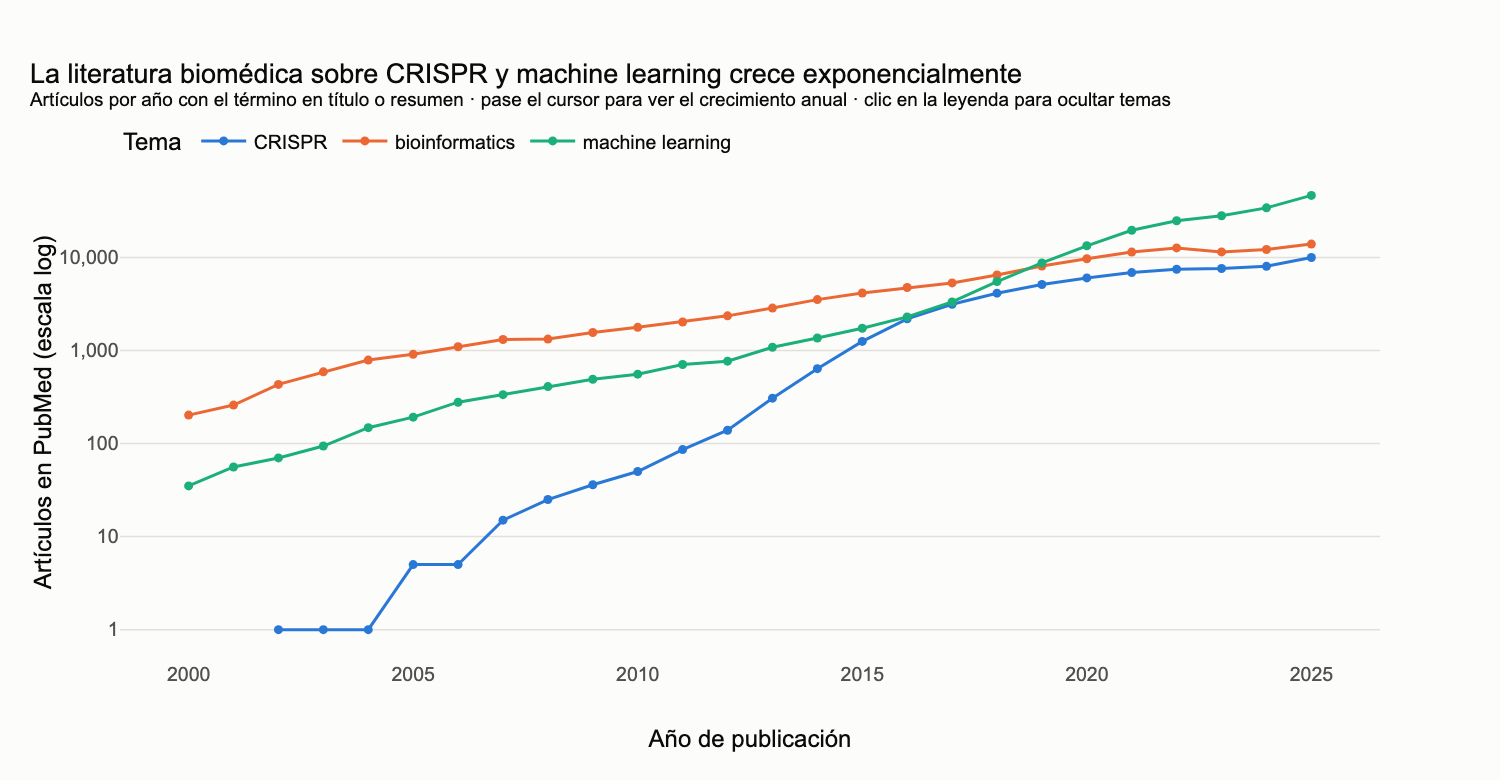

In [13]:
pubmed["growth_%"] = pubmed.groupby("topic")["articles"].pct_change() * 100
fig = px.line(pubmed[pubmed["articles"] > 0], x="year", y="articles", color="topic", markers=True, log_y=True,
              color_discrete_sequence=ec.CATEGORICAL,
              custom_data=["topic", "growth_%"],
              labels={"year": "Año de publicación", "articles": "Artículos en PubMed (escala log)", "topic": "Tema"})
fig.update_traces(hovertemplate="<b>%{customdata[0]}</b> · %{x}<br>%{y:,} artículos"
                                "<br>cambio vs. año anterior: %{customdata[1]:+.0f} %<extra></extra>")
fig.update_layout(title=dict(text="La literatura biomédica sobre CRISPR y machine learning crece exponencialmente"
                                  "<br><sup>Artículos por año con el término en título o resumen · pase el cursor "
                                  "para ver el crecimiento anual · clic en la leyenda para ocultar temas</sup>"),
                  height=520, margin=dict(t=110), legend=dict(orientation="h", yanchor="bottom", y=1.0, x=0))
fig.update_yaxes(dtick=1, tickformat=",")                  # sólo potencias de 10: 1, 10, 100, 1 000…
fig.show()

> 🔎 **Qué observamos.** En escala logarítmica, una **recta** significa crecimiento **exponencial**: el número de
> artículos se multiplica por un factor constante cada año. CRISPR tiene apenas decenas de artículos al año hasta 2012 (el
> año del artículo de Jinek, Doudna y Charpentier) y luego explota. La pendiente de cada recta nos dirá el **tiempo de
> duplicación** (Ejercicio 2).

## 5. 🧪 Ensembl: el modelo génico de *TP53*

Ya descargamos el gen de Ensembl con `expand=1`, que incluye **todos sus transcritos** y los **exones** de cada uno.
Un gen no es un bloque continuo: está formado por **exones** (fragmentos que llegan al ARN maduro) separados por
**intrones** (que se eliminan en el *splicing*). Dentro de los exones, sólo una parte se traduce (la **CDS**, de
*coding sequence*); los extremos que no se traducen son las **UTR** (*untranslated regions*).

Piense en una película que se filmó con muchas escenas extra: los exones son las escenas que quedan en el corte
final, los intrones son las que se descartan en la edición, y las UTR son los créditos al inicio y al final: forman
parte de la película, pero no de la historia.

In [14]:
exons = sorted(canon["Exon"], key=lambda e: e["start"])
cds_start, cds_end = canon["Translation"]["start"], canon["Translation"]["end"]
exon_len = sum(e["end"] - e["start"] + 1 for e in exons)
print(f"Transcrito canónico {canon['id']}.{canon['version']} ({canon['display_name']}), hebra {canon['strand']:+d}")
print(f"{len(exons)} exones · {exon_len:,} nt de ARN maduro de un locus de {canon['end'] - canon['start'] + 1:,} pb "
      f"→ {exon_len / (canon['end'] - canon['start'] + 1):.1%} es exónico")
print(f"CDS: {cds_start:,}–{cds_end:,} · proteína {canon['Translation']['id']} de {canon['Translation']['length']} aa")

Transcrito canónico ENST00000269305.9 (TP53-201), hebra -1
11 exones · 2,512 nt de ARN maduro de un locus de 19,070 pb → 13.2% es exónico
CDS: 7,669,609–7,676,594 · proteína ENSP00000269305 de 393 aa


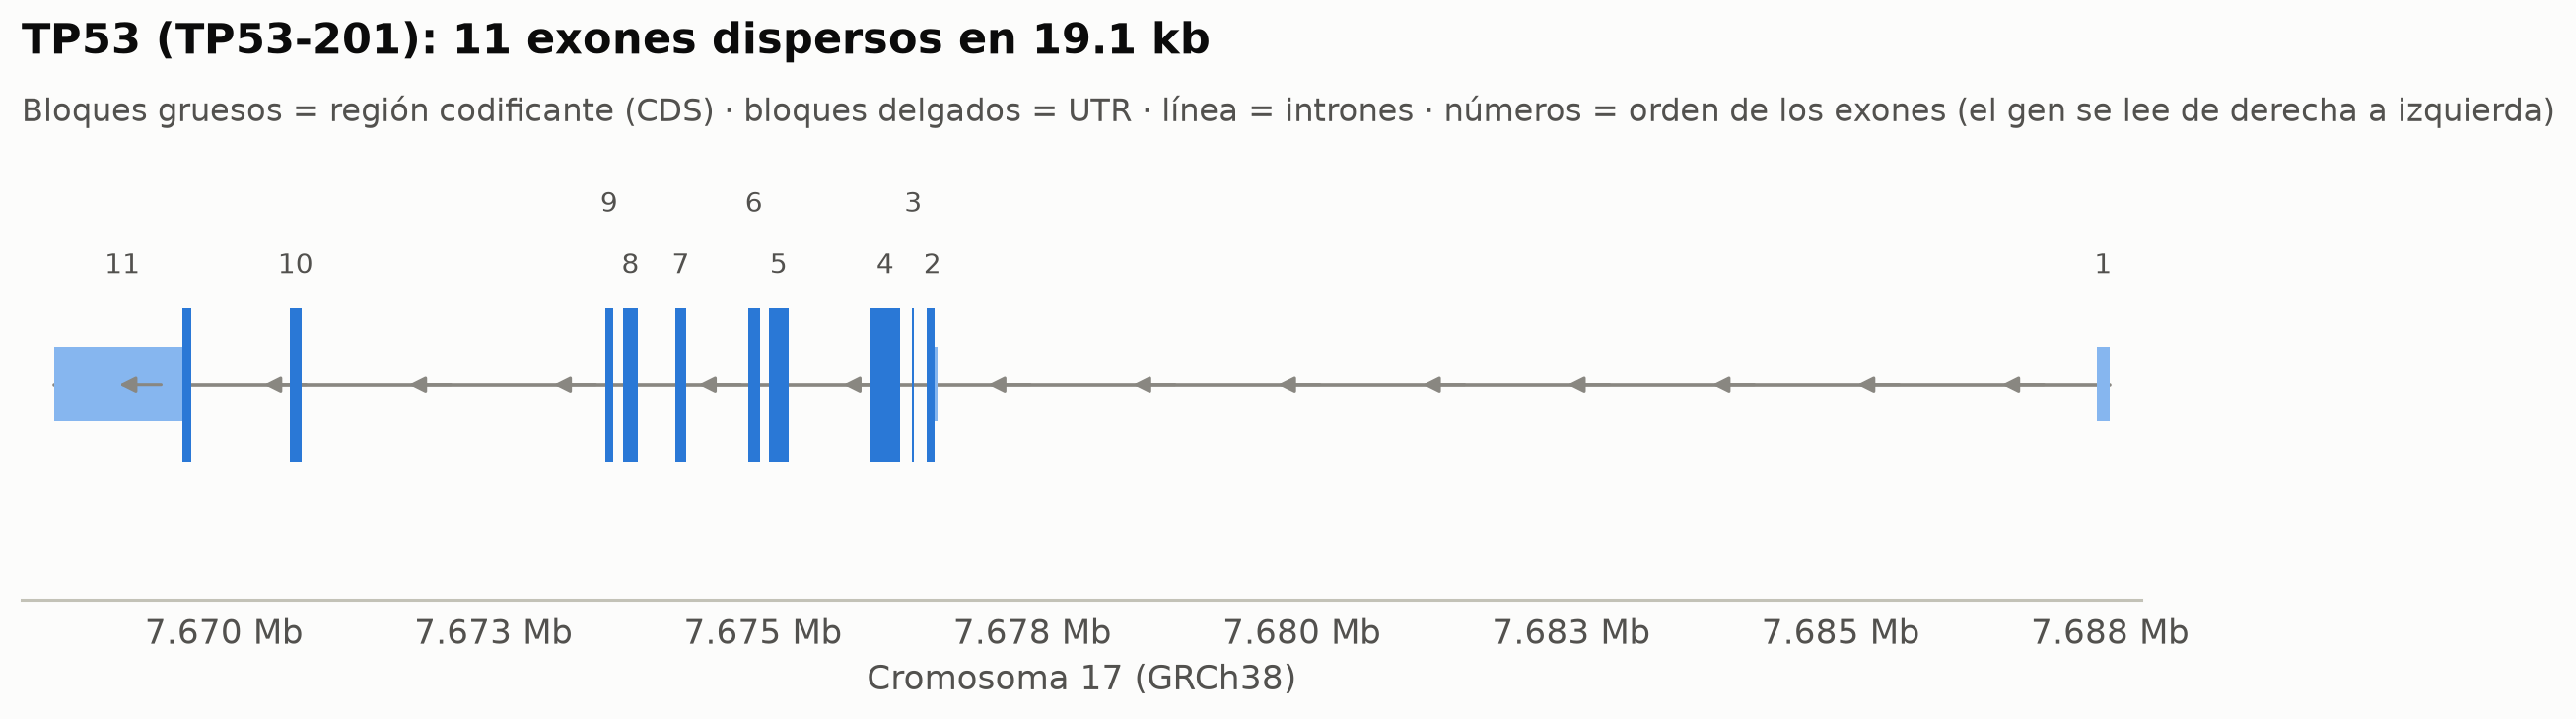

In [15]:
# Modelo génico: exones (UTR delgado, CDS grueso) e intrones, en el sentido de lectura del gen
fig, ax = plt.subplots(figsize=(12, 3.2))
y = 0
g_start, g_end = canon["start"], canon["end"]
ax.plot([g_start, g_end], [y, y], color=ec.MUTED, lw=1.2, zorder=1)
# flechas que indican la dirección de transcripción (hebra −: hacia la izquierda)
for xa in np.linspace(g_start + 800, g_end - 800, 14):
    ax.annotate("", xy=(xa - 250, y), xytext=(xa + 250, y), arrowprops=dict(arrowstyle="-|>", color=ec.MUTED, lw=1))
order = sorted(exons, key=lambda e: -e["start"])       # exón 1 = el de más a la derecha (hebra −)
last_x, lift = None, 0
for i, e in enumerate(order, 1):
    s, t = e["start"], e["end"]
    ax.add_patch(plt.Rectangle((s, y - 0.12), t - s, 0.24, color=ec.SEQ_BLUE[3], lw=0, zorder=2))     # UTR
    cs, ct = max(s, cds_start), min(t, cds_end)
    if cs < ct:
        ax.add_patch(plt.Rectangle((cs, y - 0.25), ct - cs, 0.5, color=ec.BLUE, lw=0, zorder=3))      # CDS
    xm = (s + t) / 2
    lift = 0.2 - lift if (last_x is not None and abs(last_x - xm) < 400) else 0   # alterna altura si están cerca
    ax.text(xm, y + 0.36 + lift, str(i), ha="center", fontsize=9, color=ec.INK_2)
    last_x = xm
ax.set_ylim(-0.7, 0.8); ax.set_yticks([]); ax.grid(False)
for s in ("left",): ax.spines[s].set_visible(False)
ax.set_xlim(g_start - 300, g_end + 300)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e6:.3f} Mb"))
ax.set_xlabel(f"Cromosoma {tp53_ens['seq_region_name']} ({tp53_ens['assembly_name']})")
ec.title(ax, f"TP53 ({canon['display_name']}): {len(exons)} exones dispersos en {(g_end - g_start + 1)/1000:.1f} kb",
         "Bloques gruesos = región codificante (CDS) · bloques delgados = UTR · línea = intrones · "
         "números = orden de los exones (el gen se lee de derecha a izquierda)")
plt.show()

> 🔎 **Qué observamos.** El exón 1 (a la derecha, porque el gen está en la hebra −) es **completamente no
> codificante**: la proteína empieza en el exón 2. Más del 90 % del locus es intrón. Un gen humano típico se parece
> más a un archipiélago que a un continente.

### Todos los transcritos del gen

Ensembl reporta decenas de transcritos para *TP53*: distintas combinaciones de exones (*splicing* alternativo),
distintos inicios de transcripción y algunos transcritos que no producen proteína. El gráfico interactivo permite
explorarlos: pase el cursor sobre cada exón para ver sus coordenadas.

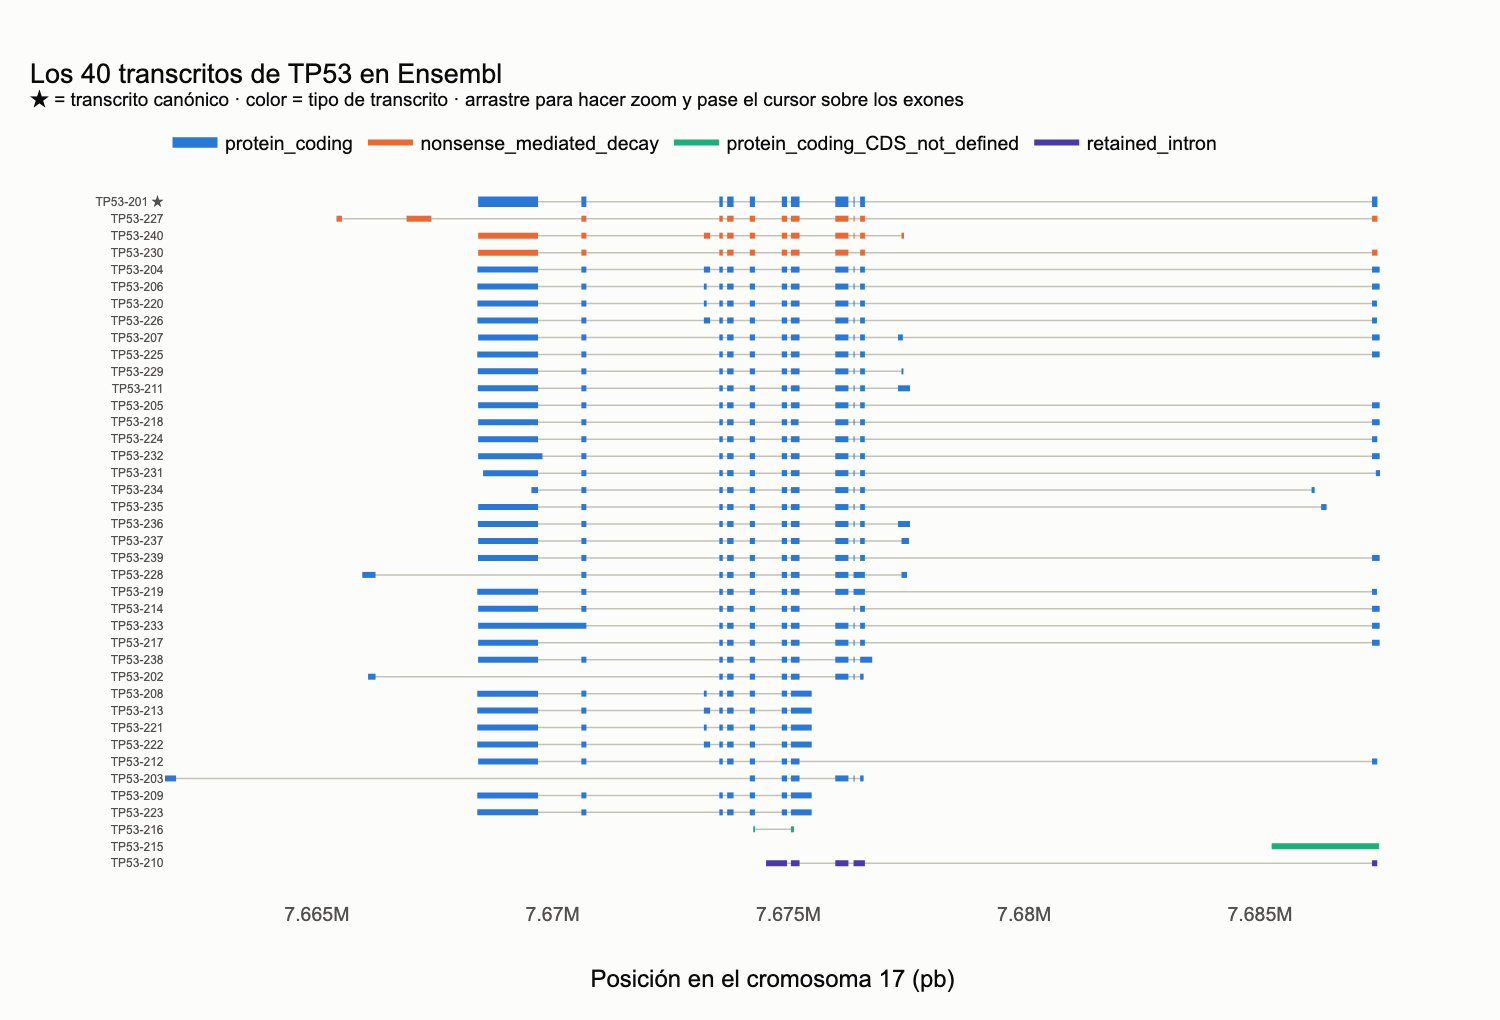

In [16]:
tx = sorted(tp53_ens["Transcript"], key=lambda t: (not t.get("is_canonical"), t["biotype"], -len(t["Exon"])))
biotype_color = {"protein_coding": ec.BLUE, "nonsense_mediated_decay": ec.ORANGE,
                 "retained_intron": ec.VIOLET, "protein_coding_CDS_not_defined": ec.AQUA}
fig = go.Figure()
shown = set()
for row, t in enumerate(tx):
    col = biotype_color.get(t["biotype"], ec.MUTED)
    fig.add_trace(go.Scatter(x=[t["start"], t["end"]], y=[row, row], mode="lines",
                             line=dict(color=ec.BASELINE, width=1), hoverinfo="skip", showlegend=False))
    xs, ys, texts = [], [], []
    for k, e in enumerate(sorted(t["Exon"], key=lambda e: -e["start"]), 1):
        xs += [e["start"], e["end"], None]; ys += [row, row, None]
        texts += [f"{t['display_name']} ({t['id']})<br>exón {k}: {e['start']:,}–{e['end']:,}"
                  f" ({e['end'] - e['start'] + 1} nt)<br>tipo: {t['biotype']}"] * 2 + [None]
    fig.add_trace(go.Scatter(x=xs, y=ys, mode="lines", line=dict(color=col, width=7 if t.get("is_canonical") else 4),
                             text=texts, hovertemplate="%{text}<extra></extra>", name=t["biotype"],
                             legendgroup=t["biotype"], showlegend=t["biotype"] not in shown))
    shown.add(t["biotype"])
fig.update_yaxes(tickvals=list(range(len(tx))), ticktext=[t["display_name"] + (" ★" if t.get("is_canonical") else "")
                                                        for t in tx], autorange="reversed", showgrid=False,
                 tickfont=dict(size=8))
fig.update_xaxes(title=f"Posición en el cromosoma {tp53_ens['seq_region_name']} (pb)")
fig.update_layout(title=dict(text=f"Los {len(tx)} transcritos de TP53 en Ensembl"
                                  "<br><sup>★ = transcrito canónico · color = tipo de transcrito · arrastre para "
                                  "hacer zoom y pase el cursor sobre los exones</sup>"),
                  height=680, margin=dict(l=110, t=110), legend=dict(orientation="h", yanchor="bottom", y=1.0, x=0))
fig.show()

✅ **Compruebe su comprensión.** ¿Por qué no basta con decir "la proteína del gen *TP53*"? ¿Qué información extra
debe dar para que otra persona sepa exactamente de qué secuencia habla? (Pista: `ENST…` **y** su versión.)

## 6. 🧪 UniProt: dominios de p53 y el mapa de sus mutaciones

UniProtKB/Swiss-Prot es la enciclopedia de proteínas: para cada una resume, con referencias, su función, sus
**regiones** (dominios, motivos, zonas de interacción), sus modificaciones y sus **variantes naturales**
conocidas. La entrada de p53 humana es `P04637`.

In [17]:
UNIPROT = "https://rest.uniprot.org/uniprotkb"
up = fetch("uniprot_P04637.json", f"{UNIPROT}/P04637.json", "uniprot")
audit = up["entryAudit"]
print(f"{up['primaryAccession']} · {up['proteinDescription']['recommendedName']['fullName']['value']} "
      f"({up['genes'][0]['geneName']['value']}, {up['organism']['scientificName']})")
print(f"Longitud: {up['sequence']['length']} aa · versión de secuencia {audit['sequenceVersion']} · "
      f"versión de la entrada {audit['entryVersion']} (actualizada {audit['lastAnnotationUpdateDate']})")
print("¿Misma secuencia que RefSeq NP_000537.3?", up["sequence"]["value"] == p53_seq)

features = pd.DataFrame([{"type": f["type"], "description": f.get("description", ""),
                          "start": f["location"]["start"]["value"], "end": f["location"]["end"]["value"]}
                         for f in up["features"]])
features["type"].value_counts().head(10).to_frame("n")

P04637 · Cellular tumor antigen p53 (TP53, Homo sapiens)
Longitud: 393 aa · versión de secuencia 4 · versión de la entrada 315 (actualizada 2026-09-02)
¿Misma secuencia que RefSeq NP_000537.3? True


,n
type,
Natural variant,1363
Mutagenesis,38
Modified residue,30
Helix,21
Region,20
Beta strand,17
Turn,7
Cross-link,6
Alternative sequence,6


Las **variantes naturales** son la parte más llamativa: más de mil cambios de un aminoácido documentados, la gran
mayoría **mutaciones somáticas** encontradas en tumores. ¿Se reparten uniformemente a lo largo de la proteína, o se
concentran en ciertos lugares?

Un detalle importante antes de contar: UniProt registra cada **cambio distinto** documentado (por ejemplo R273H y
R273C son dos entradas), no cuántas veces aparece en los tumores. Contar entradas por posición mide entonces qué tan
**diversas** son las mutaciones documentadas en cada residuo.

🤔 **Antes de ejecutar, prediga:** el dominio de unión al ADN (aminoácidos 102–292) ocupa $191/393 \approx 49\,\%$
de la proteína. Si las variantes cayeran al azar, ~49 % de ellas estarían en ese dominio. ¿Qué fracción espera
observar?

In [18]:
variants = features[features["type"] == "Natural variant"].copy()
variants["pos"] = variants["start"]
per_pos = variants.groupby("pos").agg(n=("description", "size"),
                                       example=("description", lambda s: s.iloc[0][:70])).reset_index()
per_pos["wt"] = per_pos["pos"].map(lambda p: up["sequence"]["value"][p - 1])
L = up["sequence"]["length"]
mean_per_pos = len(variants) / L
in_dbd = variants["pos"].between(102, 292).mean()
print(f"{len(variants)} variantes en {per_pos.shape[0]} posiciones · promedio: {mean_per_pos:.1f} por posición")
print(f"Fracción de variantes dentro del dominio de unión al ADN: {in_dbd:.1%} (esperado al azar: {191/L:.1%})")
per_pos.sort_values("n", ascending=False).head(8)

1363 variantes en 332 posiciones · promedio: 3.5 por posición
Fracción de variantes dentro del dominio de unión al ADN: 77.2% (esperado al azar: 48.6%)


,pos,n,example,wt
215,245,11,in sporadic cancers; somatic mutation; dbSNP:r...,G
219,249,10,in a sporadic cancer; somatic mutation,R
229,259,9,in a sporadic cancer; somatic mutation,D
251,281,9,in sporadic cancers; somatic mutation,D
217,247,9,in a sporadic cancer; somatic mutation,N
128,158,9,in sporadic cancers; somatic mutation; dbSNP:r...,R
243,273,9,in LFS; germline mutation and in sporadic canc...,R
102,132,9,in a sporadic cancer; somatic mutation,K


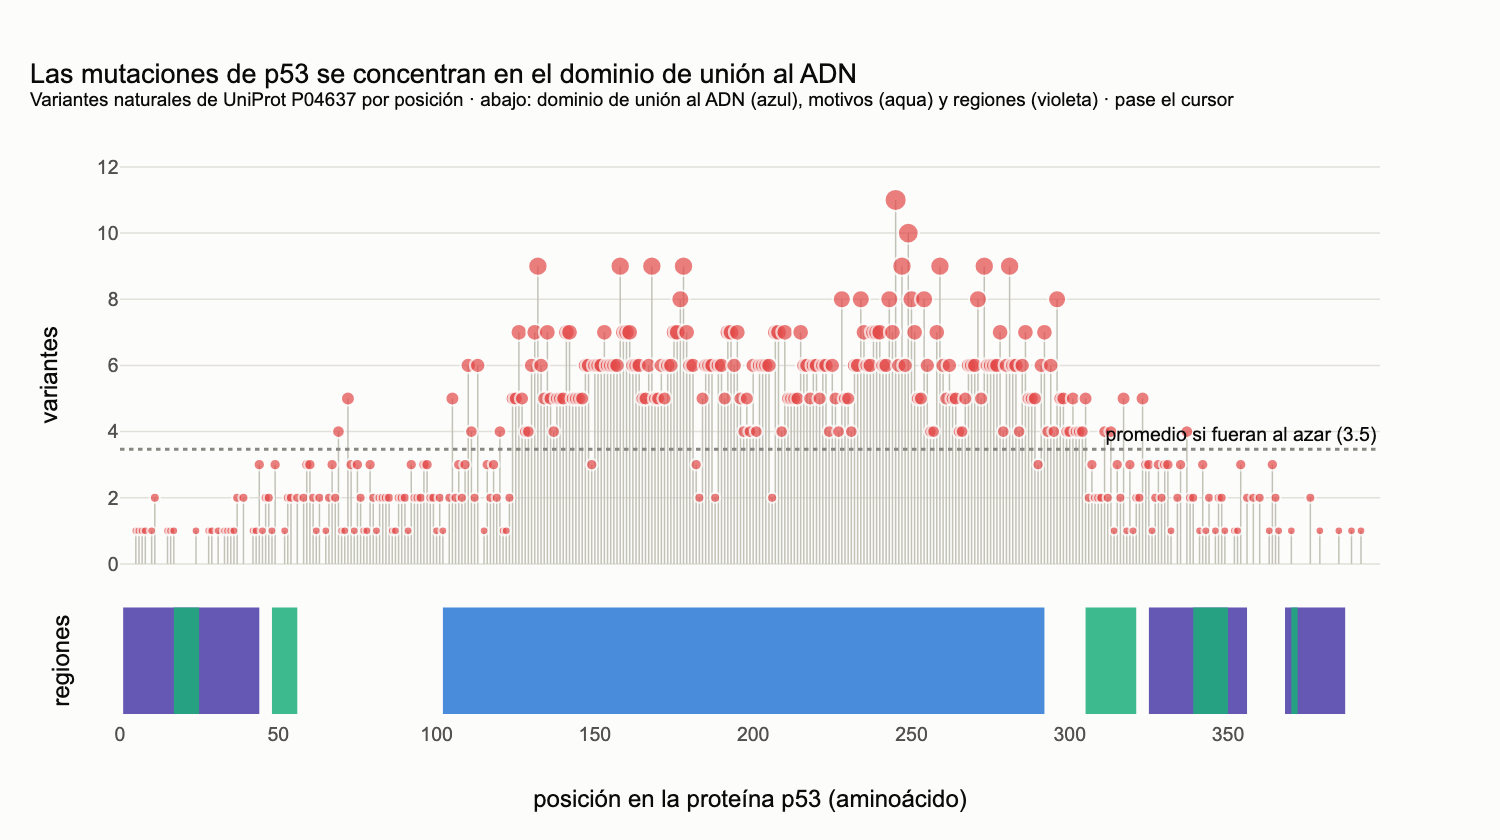

In [19]:
# Mapa interactivo tipo "lollipop": variantes por posición + regiones funcionales de UniProt
tracks = features[features["type"].isin(["DNA binding", "Motif"]) |
                  ((features["type"] == "Region") & features["description"].isin(
                      ["Transcription activation (acidic)", "Oligomerization", "Basic (repression of DNA-binding)"]))]
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.78, 0.22], vertical_spacing=0.03)
stems_x = np.column_stack([per_pos["pos"], per_pos["pos"], np.full(len(per_pos), np.nan)]).ravel()
stems_y = np.column_stack([np.zeros(len(per_pos)), per_pos["n"], np.full(len(per_pos), np.nan)]).ravel()
fig.add_trace(go.Scatter(x=stems_x, y=stems_y, mode="lines", line=dict(color=ec.BASELINE, width=1),
                         hoverinfo="skip", showlegend=False), row=1, col=1)
fig.add_trace(go.Scatter(x=per_pos["pos"], y=per_pos["n"], mode="markers",
                         marker=dict(size=np.clip(per_pos["n"] * 0.9 + 5, 5, 22), color=ec.RED,
                                     line=dict(color=ec.SURFACE, width=1.5)),
                         customdata=np.column_stack([per_pos["wt"], per_pos["example"]]),
                         hovertemplate="posición %{x} (%{customdata[0]})<br>%{y} variantes documentadas"
                                       "<br>ej.: %{customdata[1]}<extra></extra>", showlegend=False), row=1, col=1)
fig.add_hline(y=mean_per_pos, line=dict(color=ec.MUTED, dash="dot"), row=1, col=1,
              annotation_text=f"promedio si fueran al azar ({mean_per_pos:.1f})", annotation_position="top right")
track_color = {"DNA binding": ec.BLUE, "Motif": ec.AQUA, "Region": ec.VIOLET}
for _, r in tracks.iterrows():
    fig.add_trace(go.Scatter(x=[r.start, r.end, r.end, r.start, r.start], y=[0, 0, 1, 1, 0], fill="toself",
                             mode="lines", line=dict(width=0), fillcolor=track_color[r.type], opacity=0.85,
                             name=r.type, legendgroup=r.type, showlegend=False,
                             hovertemplate=f"<b>{r.type}</b>: {r.description}<br>{r.start}–{r.end}<extra></extra>"),
                  row=2, col=1)
fig.update_yaxes(title_text="variantes", row=1, col=1)
fig.update_yaxes(showticklabels=False, showgrid=False, row=2, col=1, title_text="regiones")
fig.update_xaxes(title_text="posición en la proteína p53 (aminoácido)", row=2, col=1, range=[0, L + 5])
fig.update_layout(title=dict(text="Las mutaciones de p53 se concentran en el dominio de unión al ADN"
                                  "<br><sup>Variantes naturales de UniProt P04637 por posición · abajo: dominio de unión "
                                  "al ADN (azul), motivos (aqua) y regiones (violeta) · pase el cursor</sup>"),
                  height=560, margin=dict(t=110))
fig.show()

> 🔎 **Qué observamos.** Las variantes **no** están repartidas al azar: cerca de **tres de cada cuatro** caen en el
> **dominio de unión al ADN**, que es apenas la mitad de la proteína. Las posiciones con más variantes distintas
> (G245, R249, R273…) coinciden con varios de los **puntos calientes** clásicos del cáncer; según las bases
> especializadas en mutaciones tumorales, los más frecuentes en pacientes son R175, G245, R248, R249, R273 y R282.
> Una p53 que no puede unirse al ADN no puede activar sus genes blanco, y la célula pierde su freno contra el cáncer.
> En la siguiente sección veremos estos residuos en 3D.

## 7. 🧪 PDB: las estructuras 3D de p53

El **Protein Data Bank** es el archivo primario de estructuras tridimensionales. La interfaz moderna del RCSB PDB
tiene dos APIs:

* **Search API** (`search.rcsb.org`): ¿qué entradas cumplen un criterio? Aquí: "contienen la proteína UniProt P04637".
* **Data API** (`data.rcsb.org`, en lenguaje **GraphQL**): para esas entradas, deme *exactamente* los campos que
  pido (método, resolución, fecha…). GraphQL es como un formulario donde usted marca las casillas que quiere
  recibir, en lugar de recibir el expediente completo.

Un concepto clave es la **resolución** (en ångström, Å): el tamaño del detalle más fino que se puede distinguir en
el mapa experimental. **Menor es mejor**: a ~1.5 Å se ven átomos individuales; a ~3.5 Å se distingue la forma de las
cadenas laterales, pero no mucho más.

In [20]:
query = {"query": {"type": "terminal", "service": "text",
                   "parameters": {"attribute": "rcsb_polymer_entity_container_identifiers."
                                               "reference_sequence_identifiers.database_accession",
                                  "operator": "exact_match", "value": "P04637"}},
         "return_type": "entry", "request_options": {"return_all_hits": True}}
hits = fetch("rcsb_search_P04637.json", "https://search.rcsb.org/rcsbsearch/v2/query", "rcsb", json_body=query)
pdb_ids = sorted(h["identifier"] for h in hits["result_set"])
print(f"Search API → {hits['total_count']} entradas del PDB contienen p53 humana. Ej.: {pdb_ids[:8]}")

gql = """query($ids: [String!]!) { entries(entry_ids: $ids) {
  rcsb_id exptl { method } rcsb_entry_info { resolution_combined }
  rcsb_accession_info { initial_release_date } struct { title } } }"""
meta = fetch("rcsb_graphql_P04637_entries.json", "https://data.rcsb.org/graphql", "rcsb",
             json_body={"query": gql, "variables": {"ids": pdb_ids}})
# Nota: los modelos integrativos (combinan varios métodos) no declaran un único método experimental
pdb = pd.DataFrame([{"pdb_id": e["rcsb_id"],
                     "method": e["exptl"][0]["method"] if e["exptl"] else "INTEGRATIVE",
                     "resolution_A": (e["rcsb_entry_info"]["resolution_combined"] or [np.nan])[0],
                     "year": int(e["rcsb_accession_info"]["initial_release_date"][:4]),
                     "title": e["struct"]["title"]} for e in meta["data"]["entries"]])
pdb.head()

Search API → 323 entradas del PDB contienen p53 humana. Ej.: ['1A1U', '1AIE', '1C26', '1DT7', '1GZH', '1H26', '1HS5', '1JSP']


,pdb_id,method,resolution_A,year,title
0,1AIE,X-RAY DIFFRACTION,1.50,1997,P53 TETRAMERIZATION DOMAIN CRYSTAL STRUCTURE
1,1DT7,SOLUTION NMR,NaN,2000,SOLUTION STRUCTURE OF THE C-TERMINAL NEGATIVE ...
2,1GZH,X-RAY DIFFRACTION,2.60,2002,Crystal structure of the BRCT domains of human...
3,1H26,X-RAY DIFFRACTION,2.24,2003,CDK2/CyclinA in complex with an 11-residue rec...
4,1HS5,SOLUTION NMR,NaN,2001,NMR SOLUTION STRUCTURE OF DESIGNED P53 DIMER


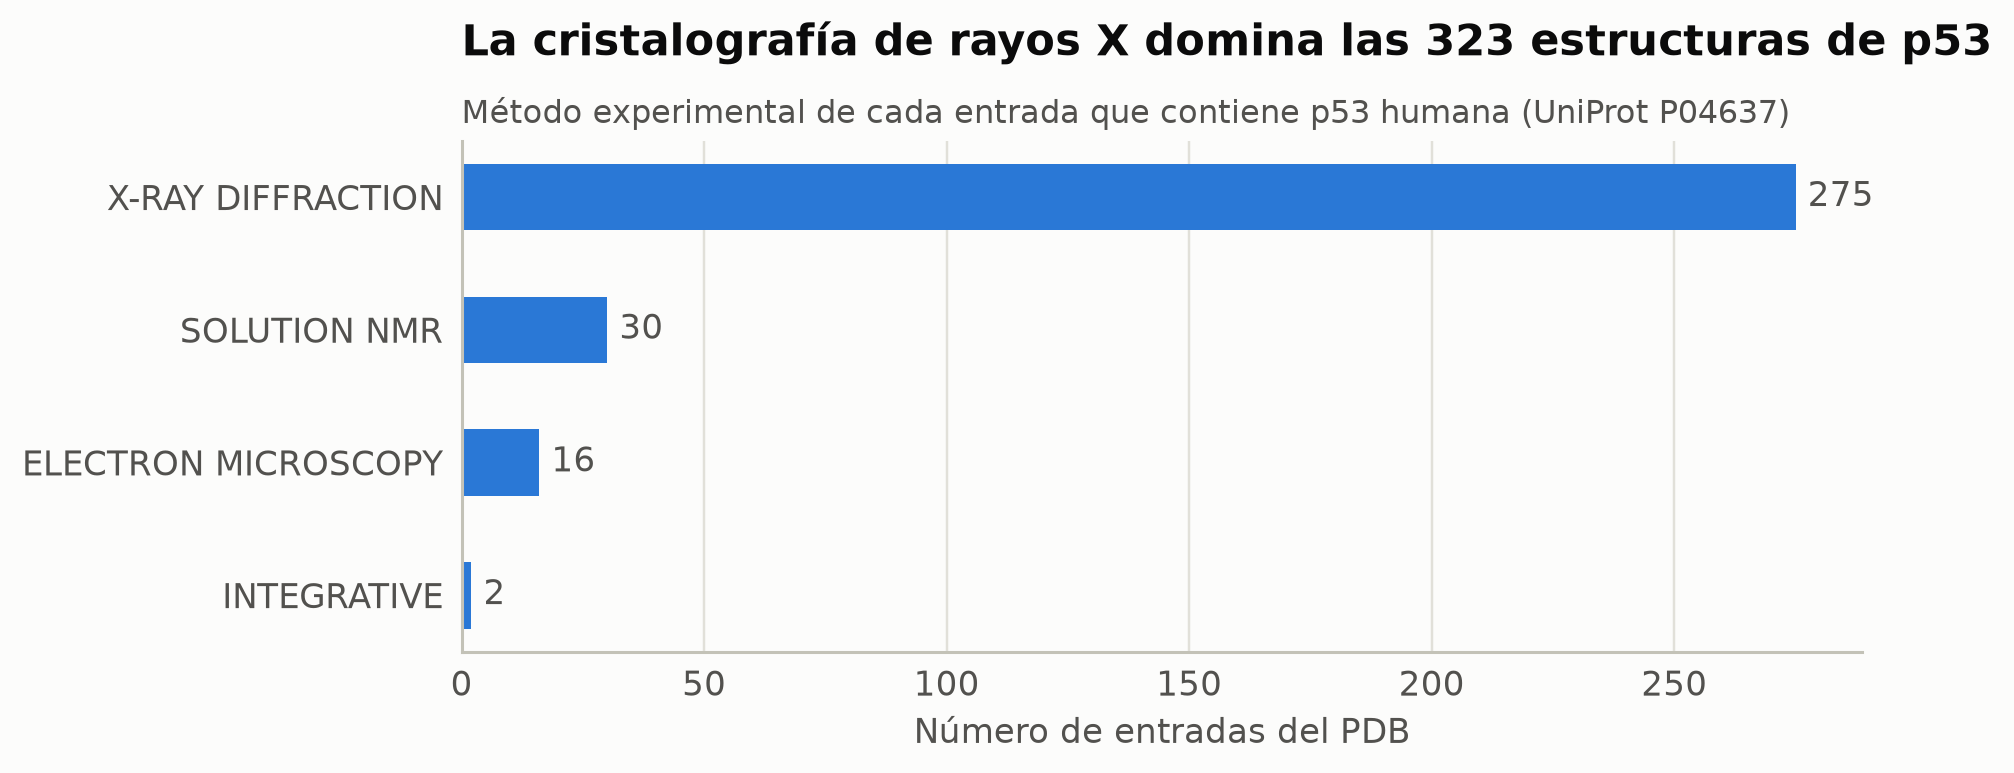

In [21]:
method_counts = pdb["method"].value_counts()
fig, ax = plt.subplots(figsize=(8.5, 3.4))
bars = ax.barh(method_counts.index[::-1], method_counts.values[::-1], color=ec.BLUE, height=0.5)
ax.bar_label(bars, padding=4, color=ec.INK_2)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_xlabel("Número de entradas del PDB")
ec.title(ax, f"La cristalografía de rayos X domina las {len(pdb)} estructuras de p53",
         "Método experimental de cada entrada que contiene p53 humana (UniProt P04637)")
plt.show()

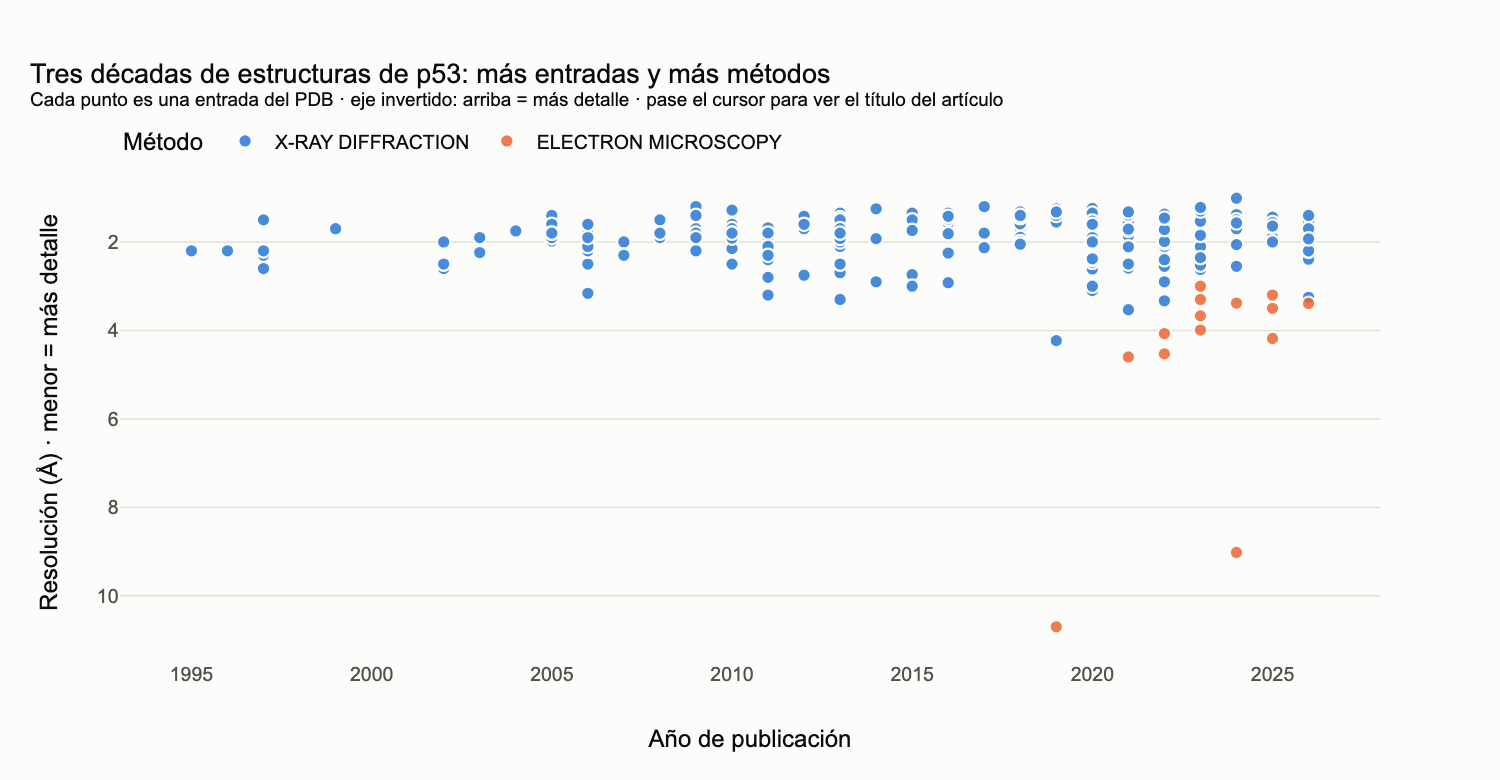

In [22]:
pdb_res = pdb.dropna(subset=["resolution_A"])
fig = px.scatter(pdb_res, x="year", y="resolution_A", color="method", hover_name="pdb_id",
                 hover_data={"title": True, "year": True, "resolution_A": ":.2f", "method": False},
                 color_discrete_sequence=ec.CATEGORICAL,
                 labels={"year": "Año de publicación", "resolution_A": "Resolución (Å) · menor = más detalle",
                         "method": "Método"})
fig.update_traces(marker=dict(size=9, line=dict(color=ec.SURFACE, width=1.5)), opacity=0.85)
fig.update_yaxes(autorange="reversed")
fig.update_layout(title=dict(text="Tres décadas de estructuras de p53: más entradas y más métodos"
                                  "<br><sup>Cada punto es una entrada del PDB · eje invertido: arriba = más "
                                  "detalle · pase el cursor para ver el título del artículo</sup>"),
                  height=520, margin=dict(t=110), legend=dict(orientation="h", yanchor="bottom", y=1.0, x=0))
fig.show()

> 🔎 **Qué observamos.** Las primeras estructuras (años 90) son pocas; hoy hay cientos, muchas de ellas del dominio
> de unión al ADN con **fármacos candidatos** que intentan "rescatar" p53 mutada. La criomicroscopía electrónica
> (EM) aparece en los últimos años y, en general, con resoluciones más modestas que los rayos X.

### Ver la estructura: p53 abrazando el ADN (PDB 1TSR)

La entrada **1TSR** es un clásico: el dominio de unión al ADN de p53 unido a su secuencia blanco. Primero pedimos
sus metadatos para saber qué cadenas son proteína y cuáles ADN (¡no las adivinamos!), y luego la mostramos en 3D
con `py3Dmol`. Resaltamos en rojo las posiciones "calientes" que encontramos en UniProt.

In [23]:
entry_q = """{ entry(entry_id: "1TSR") { rcsb_entry_info { resolution_combined }
  polymer_entities { entity_poly { pdbx_strand_id type } rcsb_polymer_entity { pdbx_description } } } }"""
tsr = fetch("rcsb_graphql_1TSR.json", "https://data.rcsb.org/graphql", "rcsb", json_body={"query": entry_q})["data"]["entry"]
chains = {"protein": [], "dna": []}
for ent in tsr["polymer_entities"]:
    kind = "dna" if "deoxyribonucleotide" in ent["entity_poly"]["type"] else "protein"
    chains[kind] += ent["entity_poly"]["pdbx_strand_id"].split(",")
hotspots = sorted(per_pos.loc[per_pos["n"] >= 9, "pos"].tolist())      # posiciones con ≥ 9 variantes distintas
print(f"1TSR · resolución {tsr['rcsb_entry_info']['resolution_combined'][0]} Å · cadenas de proteína {chains['protein']}"
      f" · cadenas de ADN {chains['dna']}")
print("Posiciones más mutadas según UniProt (se resaltan en rojo):", hotspots)

1TSR · resolución 2.2 Å · cadenas de proteína ['A', 'B', 'C'] · cadenas de ADN ['E', 'F']
Posiciones más mutadas según UniProt (se resaltan en rojo): [132, 158, 168, 178, 245, 247, 249, 259, 273, 281]


In [24]:
try:
    import py3Dmol
except ImportError:
    %pip install -q py3Dmol
    import py3Dmol

view = py3Dmol.view(query="pdb:1TSR", width=760, height=480)
view.setStyle({"chain": chains["protein"]}, {"cartoon": {"color": "#9ec5f4"}})
view.setStyle({"chain": chains["dna"]}, {"cartoon": {"color": "#eda100"}, "stick": {"radius": 0.15}})
view.addStyle({"chain": chains["protein"], "resi": hotspots}, {"stick": {"color": "#e34948", "radius": 0.3}})
view.zoomTo({"chain": chains["dna"]})
view.show()
print("🖱️ Arrastre para girar · rueda para acercar · azul = p53 · amarillo = ADN · rojo = puntos calientes")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

🖱️ Arrastre para girar · rueda para acercar · azul = p53 · amarillo = ADN · rojo = puntos calientes


> 🔎 **Qué observamos.** Gire la molécula: varios residuos rojos quedan justo en la cara que toca el ADN (por
> ejemplo R273, que contacta el esqueleto de fosfatos) o en los lazos que sostienen esa superficie (G245, R249).
> Una sola sustitución en esos lugares basta para que p53 "suelte" el ADN o pierda su forma.
> Acabamos de conectar **tres bases de datos** (la variante en UniProt, la posición en la secuencia y el átomo en el
> PDB) para explicar un mecanismo de cáncer.

## 8. Todo junto: una tabla integrada con procedencia

Finalmente, verifiquemos los identificadores cruzados **consultando las bases**, no copiándolos de memoria: le
preguntamos a Ensembl a qué identificadores de otras bases corresponden su gen y su proteína.

In [25]:
xg = fetch("ensembl_xrefs_ENSG00000141510.json", f"{ENSEMBL}/xrefs/id/ENSG00000141510", "ensembl",
           params={"content-type": "application/json"})
xp = fetch(f"ensembl_xrefs_{canon['Translation']['id']}.json", f"{ENSEMBL}/xrefs/id/{canon['Translation']['id']}",
           "ensembl", params={"content-type": "application/json"})
def xref(items, db):
    return sorted({x["primary_id"] for x in items if x["dbname"] == db})

ids = pd.DataFrame([
    ("Gen",        "NCBI Gene",   gene_id,                                   "esearch (NCBI)"),
    ("Gen",        "Ensembl",     f"{tp53_ens['id']}.{tp53_ens['version']}", "lookup (Ensembl)"),
    ("Gen",        "HGNC",        ", ".join(xref(xg, "HGNC")),               "xrefs (Ensembl)"),
    ("Gen",        "OMIM",        ", ".join(xref(xg, "MIM_GENE")),           "xrefs (Ensembl)"),
    ("Transcrito", "Ensembl",     f"{canon['id']}.{canon['version']}",       "lookup (Ensembl)"),
    ("Proteína",   "Ensembl",     canon["Translation"]["id"],                "lookup (Ensembl)"),
    ("Proteína",   "RefSeq",      ", ".join(xref(xp, "RefSeq_peptide")),     "xrefs (Ensembl)"),
    ("Proteína",   "UniProt",     ", ".join(xref(xp, "Uniprot/SWISSPROT")),  "xrefs (Ensembl)"),
    ("Estructura", "PDB",         f"{len(pdb_ids)} entradas · ej. 1TSR",    "Search API (RCSB)"),
], columns=["level", "database", "identifier", "obtained_with"])
ids

,level,database,identifier,obtained_with
0,Gen,NCBI Gene,7157,esearch (NCBI)
1,Gen,Ensembl,ENSG00000141510.21,lookup (Ensembl)
2,Gen,HGNC,HGNC:11998,xrefs (Ensembl)
3,Gen,OMIM,191170,xrefs (Ensembl)
4,Transcrito,Ensembl,ENST00000269305.9,lookup (Ensembl)
5,Proteína,Ensembl,ENSP00000269305,lookup (Ensembl)
6,Proteína,RefSeq,"NP_000537, NP_001119584",xrefs (Ensembl)
7,Proteína,UniProt,P04637,xrefs (Ensembl)
8,Estructura,PDB,323 entradas · ej. 1TSR,Search API (RCSB)


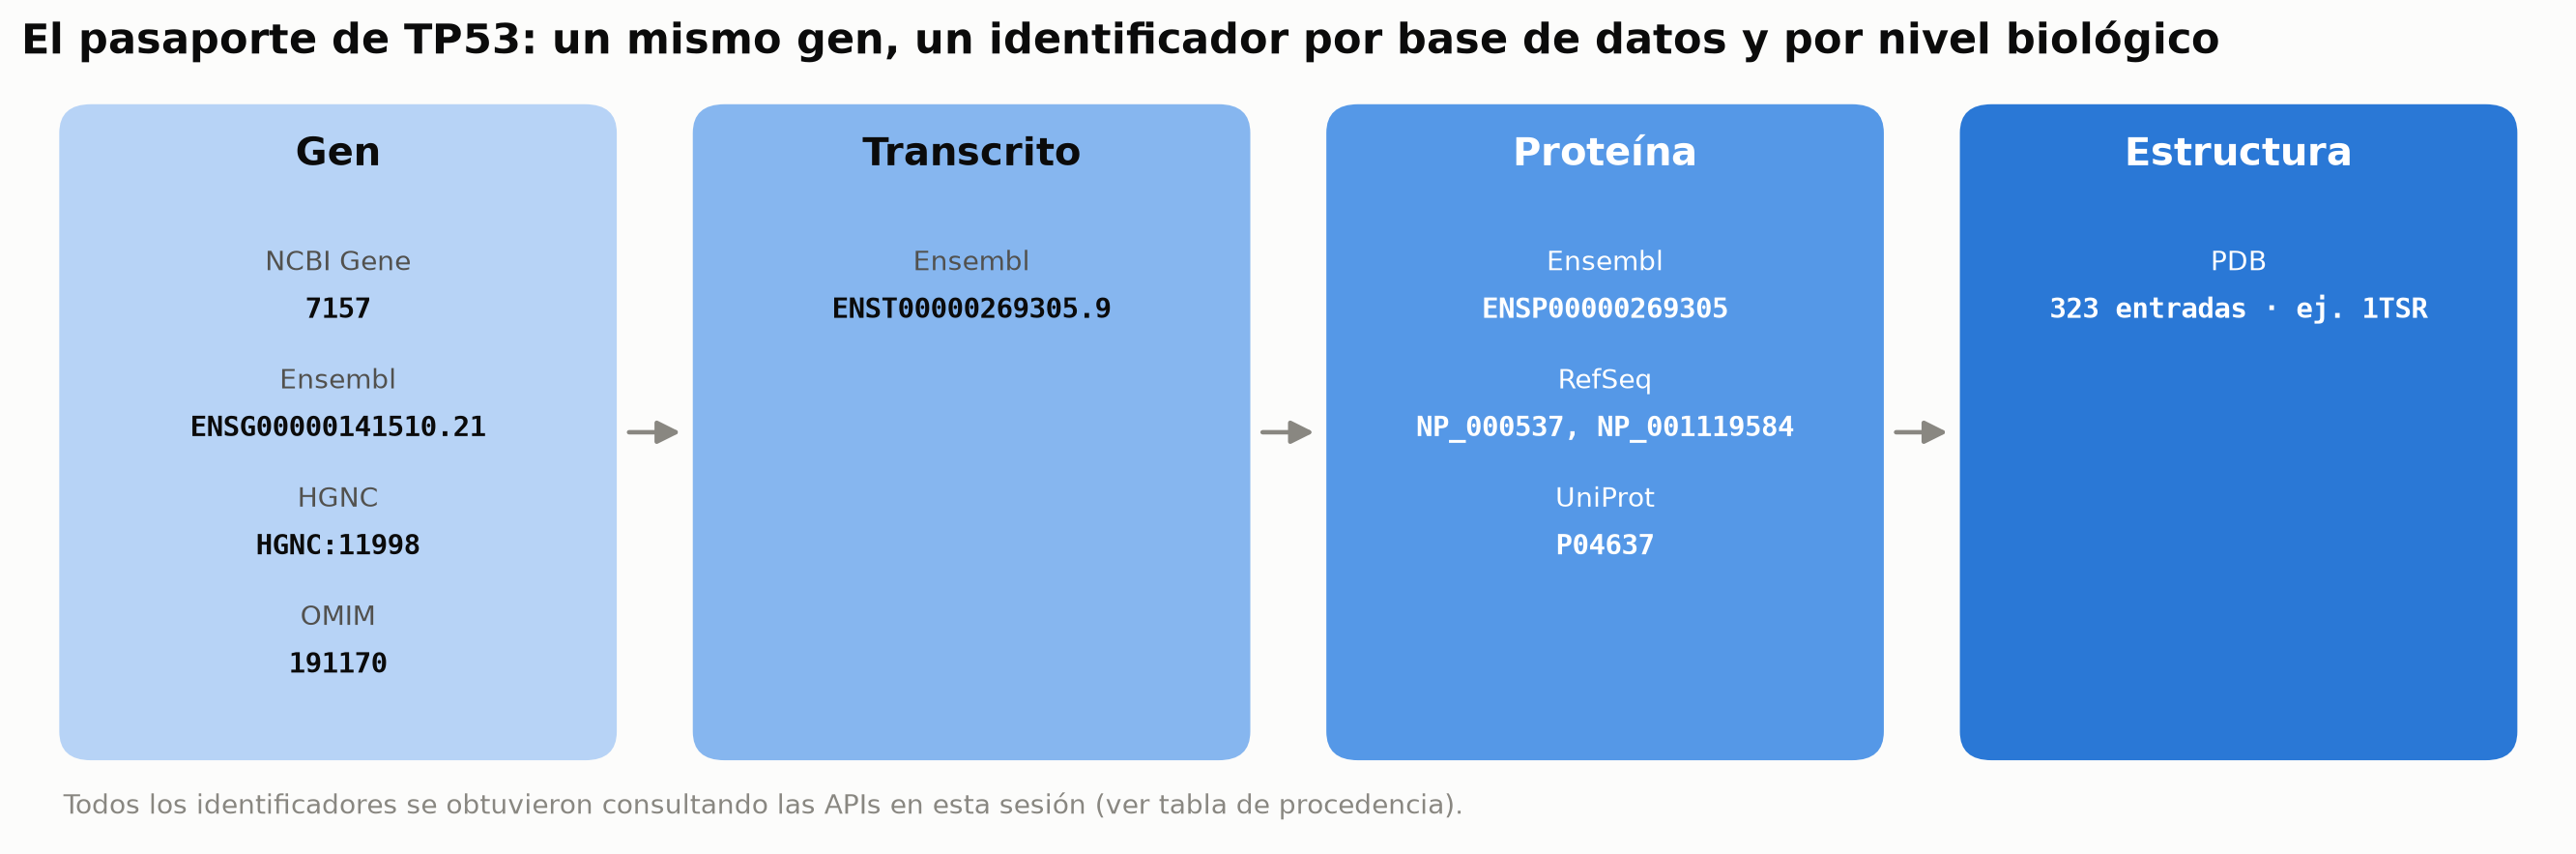

In [26]:
# Diagrama del "pasaporte" de TP53, construido con los identificadores recién consultados
levels = ["Gen", "Transcrito", "Proteína", "Estructura"]
fig, ax = plt.subplots(figsize=(12, 3.9))
ax.set_xlim(0, 12); ax.set_ylim(-0.1, 3.8); ax.axis("off"); ax.grid(False)
for i, lev in enumerate(levels):
    x0 = 0.2 + i * 3.0
    sub = ids[ids["level"] == lev]
    ax.add_patch(FancyBboxPatch((x0, 0.3), 2.6, 3.4, boxstyle="round,pad=0.02,rounding_size=0.15",
                                fc=ec.SEQ_BLUE[1 + 2 * i], ec="none"))
    ax.text(x0 + 1.3, 3.4, lev, ha="center", fontsize=13, fontweight="bold",
            color="white" if i >= 2 else ec.INK)
    for j, (_, r) in enumerate(sub.iterrows()):
        ax.text(x0 + 1.3, 2.85 - j * 0.62, r["database"], ha="center", fontsize=9, color="white" if i >= 2 else ec.INK_2)
        ax.text(x0 + 1.3, 2.6 - j * 0.62, r["identifier"][:28], ha="center", fontsize=9.5, family="DejaVu Sans Mono",
                color="white" if i >= 2 else ec.INK, fontweight="bold")
    if i < 3:
        ax.add_patch(FancyArrowPatch((x0 + 2.65, 2.0), (x0 + 2.95, 2.0), arrowstyle="-|>", mutation_scale=16,
                                     color=ec.MUTED, lw=1.5))
ax.set_title("El pasaporte de TP53: un mismo gen, un identificador por base de datos y por nivel biológico", loc="left")
ax.text(0.2, 0.0, "Todos los identificadores se obtuvieron consultando las APIs en esta sesión (ver tabla de procedencia).",
        fontsize=9, color=ec.MUTED)
plt.show()

### El registro de procedencia

Cada llamada a `fetch()` quedó anotada. Esta tabla es lo que usted adjuntaría a los métodos de un artículo (o a su
cuaderno de laboratorio) para que otra persona pueda repetir exactamente el análisis: **qué** se pidió, **a quién**,
**cuándo** y si la respuesta vino en vivo, de la caché o del respaldo.

In [27]:
prov = pd.DataFrame(PROVENANCE)
print(f"{len(prov)} consultas registradas en esta sesión")
display(prov.groupby(["service", "source"]).size().rename("n").reset_index())
prov[["key", "service", "source", "retrieved"]].drop_duplicates("key").head(12)

89 consultas registradas en esta sesión


,service,source,n
0,ensembl,caché de la sesión,2
1,ensembl,respaldo del curso (ConnectionError),1
2,ncbi,caché de la sesión,82
3,rcsb,caché de la sesión,3
4,uniprot,caché de la sesión,1


,key,service,source,retrieved
0,ensembl_lookup_ENSG00000141510.json,ensembl,respaldo del curso (ConnectionError),2026-09-29T21:13:31
1,ncbi_esearch_gene_TP53_human.json,ncbi,caché de la sesión,2026-09-29T21:13:31
2,ncbi_esummary_gene_7157.json,ncbi,caché de la sesión,2026-09-29T21:13:31
3,ncbi_elink_gene_7157_protein_refseq.json,ncbi,caché de la sesión,2026-09-29T21:13:31
4,ncbi_efetch_NP_000537.3.fasta,ncbi,caché de la sesión,2026-09-29T21:13:31
5,pubmed_count_CRISPR_2000.json,ncbi,caché de la sesión,2026-09-29T21:13:31
6,pubmed_count_CRISPR_2001.json,ncbi,caché de la sesión,2026-09-29T21:13:31
7,pubmed_count_CRISPR_2002.json,ncbi,caché de la sesión,2026-09-29T21:13:31
8,pubmed_count_CRISPR_2003.json,ncbi,caché de la sesión,2026-09-29T21:13:31
9,pubmed_count_CRISPR_2004.json,ncbi,caché de la sesión,2026-09-29T21:13:31


**Buenas prácticas para trabajar con bases de datos** (llévelas a todos sus proyectos):

1. Registre **identificador + versión** (`NM_000546.6`, `ENST00000269305.9`, `P04637` v4), no sólo el nombre del gen.
2. Anote la **fecha** de consulta y la **versión** de la base (Ensembl release, UniProt release).
3. Use **caché**: no pregunte dos veces lo mismo.
4. Respete los **límites de uso** (≤ 3/s en el NCBI sin API key) y use reintentos con espera exponencial.
5. Para miles de registros, use las **descargas masivas** (FTP) en lugar de la API.
6. **Verifique** los cruces entre bases (como hicimos con las coordenadas NCBI vs. Ensembl y la secuencia RefSeq vs.
   UniProt).

## ✍️ Ejercicios

**Ejercicio 1 — El pasaporte de *BRCA1*.** Repita la sección 8 para el gen humano *BRCA1*: obtenga su NCBI Gene ID
con `esearch`, su identificador de Ensembl (endpoint `lookup/symbol/homo_sapiens/BRCA1`), su transcrito canónico y
su acceso de UniProt con `xrefs`.

**Ejercicio 2 — Tiempo de duplicación de la literatura.** Si los artículos crecen como $A(t) = A_0 e^{\lambda t}$,
la recta $\ln A = \ln A_0 + \lambda t$ tiene pendiente $\lambda$ y el **tiempo de duplicación** es
$T_2 = \ln 2 / \lambda$. Ajuste una recta a $\ln A$ para CRISPR entre 2013 y 2020 y calcule $T_2$.

**Ejercicio 3 — ¿Es azar la concentración en el dominio?** Si cada una de las $N$ variantes cayera al azar en la
proteína, el número $K$ dentro del dominio de unión al ADN seguiría una binomial $K \sim \mathrm{Bin}(N, p)$ con
$p = 191/393$ (Lección 0.1). Calcule el valor $p$ de observar tantas o más variantes en el dominio con
`scipy.stats.binomtest` y el puntaje $z = (K - Np)/\sqrt{Np(1-p)}$.

**Ejercicio 4 — Las mejores estructuras.** ¿Cuántas estructuras de rayos X de p53 tienen resolución mejor que
1.5 Å? ¿De qué año es la más antigua de ellas?

In [28]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
b_search = fetch("ncbi_esearch_gene_BRCA1_human.json", f"{EUTILS}/esearch.fcgi", "ncbi",
                 params={"db": "gene", "term": "BRCA1[sym] AND human[orgn]", "retmode": "json", **NCBI_PARAMS})
b_ens = fetch("ensembl_lookup_symbol_BRCA1.json", f"{ENSEMBL}/lookup/symbol/homo_sapiens/BRCA1", "ensembl",
              params={"expand": 1, "content-type": "application/json"})
b_canon = next(t for t in b_ens["Transcript"] if t.get("is_canonical"))
b_xp = fetch(f"ensembl_xrefs_{b_canon['Translation']['id']}.json", f"{ENSEMBL}/xrefs/id/{b_canon['Translation']['id']}",
             "ensembl", params={"content-type": "application/json"})
print("NCBI Gene:", b_search["esearchresult"]["idlist"][0])
print("Ensembl gen:", b_ens["id"], "| transcrito canónico:", b_canon["id"], f"({len(b_canon['Exon'])} exones)")
print("UniProt:", xref(b_xp, "Uniprot/SWISSPROT"), "| RefSeq:", xref(b_xp, "RefSeq_peptide")[:3])

NCBI Gene: 672
Ensembl gen: ENSG00000012048 | transcrito canónico: ENST00000357654 (23 exones)
UniProt: ['P38398'] | RefSeq: ['NP_001394527', 'NP_001394531', 'NP_001394532']


In [29]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
cr = pubmed[(pubmed["topic"] == "CRISPR") & pubmed["year"].between(2013, 2020)]
lam, ln_a0 = np.polyfit(cr["year"], np.log(cr["articles"]), 1)
print(f"λ = {lam:.3f} por año  →  T₂ = ln 2 / λ = {np.log(2) / lam:.2f} años")

λ = 0.419 por año  →  T₂ = ln 2 / λ = 1.65 años


In [30]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
from scipy import stats
N_var = len(variants); K = int(variants["pos"].between(102, 292).sum()); p_dom = 191 / L
test = stats.binomtest(K, N_var, p_dom, alternative="greater")
z = (K - N_var * p_dom) / np.sqrt(N_var * p_dom * (1 - p_dom))
print(f"K = {K} de N = {N_var} variantes en el dominio (esperadas {N_var * p_dom:.0f}) · z = {z:.1f} · p = {test.pvalue:.1e}")

K = 1052 de N = 1363 variantes en el dominio (esperadas 662) · z = 21.1 · p = 8.2e-104


In [31]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
best = pdb[(pdb["method"] == "X-RAY DIFFRACTION") & (pdb["resolution_A"] < 1.5)].sort_values("year")
print(f"{len(best)} estructuras de rayos X con resolución < 1.5 Å; la más antigua: "
      f"{best.iloc[0]['pdb_id']} ({best.iloc[0]['year']}, {best.iloc[0]['resolution_A']:.2f} Å)" if len(best) else "ninguna")

58 estructuras de rayos X con resolución < 1.5 Å; la más antigua: 1YC5 (2005, 1.40 Å)


## 📌 Resumen

* Las bases de datos se organizan en **primarias** (lo depositado), **curadas** (una entrada revisada por entidad) y
  **derivadas** (integración y contexto). Un mismo gen tiene un identificador en cada una y en cada nivel
  (gen → transcrito → proteína → estructura).
* Una **API REST** se consulta con una URL (servidor + endpoint + parámetros); la respuesta trae un **código de
  estado** y un cuerpo, normalmente **JSON**.
* Las **E-utilities** del NCBI se combinan: `esearch` → `esummary`/`elink` → `efetch`.
* Respete los **límites de uso** ($T_{\min} = N/r$), reintente con **espera exponencial** ($t_k = b\,2^k$), use
  **caché** y **respaldo**, y registre la **procedencia**.
* Cuidado con las **coordenadas**: base 0 vs. base 1 y la hebra del gen.
* Integrando NCBI, Ensembl, UniProt y PDB explicamos por qué las mutaciones de p53 en cáncer se concentran en los
  residuos que tocan el ADN.

**Próximo módulo (3):** Alineamiento de secuencias — cómo medir cuánto se parecen dos secuencias.

## 📚 Para profundizar

* Sayers, E. W. *et al.* Database resources of the National Center for Biotechnology Information. *Nucleic Acids
  Research* (número anual de bases de datos).
* The UniProt Consortium. UniProt: the Universal Protein Knowledgebase. *Nucleic Acids Research* (número anual).
* Martin, F. J. *et al.* (2023). Ensembl 2023. *Nucleic Acids Research* 51(D1): D933–D941.
* Berman, H. M. *et al.* (2000). The Protein Data Bank. *Nucleic Acids Research* 28(1): 235–242.
* Cho, Y., Gorina, S., Jeffrey, P. D. & Pavletich, N. P. (1994). Crystal structure of a p53 tumor suppressor–DNA
  complex. *Science* 265: 346–355.
* NCBI. *Entrez Programming Utilities Help* (documentación oficial de las E-utilities).

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)